# Lecture 13 — Molecular Chemistry: the Coupled Equilibrium and Continuous Opacity

*Stellar Spectroscopy from Scratch — a torch/MPS implementation, with each part validated against reference calculations*

*Yuan-Sen Ting*

*The production **NMOLEC** coupled-equilibrium solver and the **CHOP / OHOP / H$_2$-CIA** molecular continuum are rebuilt in clean **`torch`**. The lecture's added pedagogy is the **vectorization**, and it is a sharp lesson in *what vectorizes and what does not*. In Part 1 the Newton **iteration** over the $n_{\rm equa}$ unknowns is vectorized — an **autodiff Jacobian** (`torch.func.jacrev`) replaces the hand-coded `DEQ`, the residual is built **branchlessly in log space** from a precomputed incidence structure, and the linear step is a **column-scaled** `torch.linalg.solve` — but the **depth loop stays a loop** because this implementation uses a robust pressure-continuation warm start from the converged depth above; the depths are physically local, but naive batched cold starts are unreliable for this stiff system. This stiff solve is deliberately CPU/fp64. In Part 2 the continuum is a clean depth-batched `[D, F]` tabulated interpolation, vectorized over the grid and run in the notebook's working dtype. Each part ships a **comparison cell** validating the torch result against an inline fp64 reference (and the ground truth) to the documented float floor: $\sim10^{-13}$ for the equilibrium solve (CPU-fp64 reference path), $\sim6\times10^{-8}$ for the continuum (fp32 on MPS). The clean torch implementations are pedagogical reductions of the production `kgpu` engine — the notebook imports neither `kgpu` nor pykurucz.*

---

**Learning objectives.** By the end of this lecture you will be able to:

- Explain why molecular chemistry is a **coupled** problem — every molecule competes for the same atom pool and the negative ions tie the chemistry to $n_e$ — so a single $K_f$ per molecule is an *input*, not the answer; the balances must be solved **together**.
- Assemble the coupled system the production code solves: one **total-particle** equation, one **number-conservation** equation per element, and one **charge-balance** equation, with every molecule's mass-action term.
- Recast the production **NMOLEC** solver into its torch form: a **Newton iteration vectorized over the unknowns** with an **autodiff (`jacrev`) Jacobian** replacing the hand-built `DEQ`, a **branchless log-space residual** from a precomputed incidence structure, and a **column-scaled** `torch.linalg.solve` conditioning the $\sim$25-dex Jacobian — and say precisely **why this implementation keeps the depth loop** (a pressure-continuation warm-start strategy, not a physical nonlocal coupling).
- Compute the **molecular continuous opacity** of a cool dwarf — **CH** (CHOP) and **OH** (OHOP) photodissociation and **H$_2$ collision-induced absorption** (H$_2$-CIA, the Borysow tables) — as one depth-batched `[D, F]` table interpolation.
- Show that **H$_2$-CIA dominates the molecular continuum across 1–2.2 $\mu$m in this model**, and **validate** both the torch/CPU-fp64 equilibrium solver and the torch continuum against the inline fp64 reference to the documented float floor.

## Introduction

Lecture 12 synthesised a cool M dwarf's TiO band, and to do it we made two purchases on credit. We **read** the molecular number densities out of the converged model atmosphere — pykurucz's already-solved answer — and used them to drive the band opacity. And we drew the spectrum on a continuum that, for a cool star, is not the simple H$^-$ continuum of the warmer Sun. Both were taken as given. This lecture pays most of that debt: we solve the molecular chemistry ourselves and compute the CH/OH/H$_2$-CIA molecular-continuum terms from scratch. For parity with pykurucz, the continuum cell still uses the reference atmosphere-state populations as inputs; in the full pipeline those are supplied by the EOS/equilibrium stages.

The first half is the chemistry. In Lecture 12 we wrote the formation balance of a single molecule, Ti + O $\rightleftharpoons$ TiO, as a Saha-like law with one equilibrium constant $K_f(T)$. That is correct but incomplete, because the molecules are not independent. Oxygen is also pulled into CO, OH, H$_2$O, SiO, and a dozen other species, all drawing on the **same** finite supply of oxygen nuclei; carbon competes for it through CO; hydrogen becomes strongly molecular in cool, sufficiently dense layers; and negative ions, including atomic H$^-$ and any molecular ions in the table, tie the network to the **electron density**. So the populations are the solution of a **coupled** nonlinear system, solved by the production routine **NMOLEC** — a Newton–Raphson iteration with a linear solve and step damping. The second half is the continuum: **CH and OH** add bound-free photodissociation absorption in the blue, and **H$_2$ collision-induced absorption** (a transient collision complex with an induced dipole) dominates the *molecular* near-infrared continuum from 1 to 2.2 $\mu$m in this model.

Lecture 13 makes the cleanest case in the book for the principle **"vectorize what is independent; keep the loop where the robust numerical strategy needs continuation."** The coupled solve has two nested loops in its scalar form: an **inner Newton iteration** over the $n_{\rm equa}$ unknowns at a fixed depth, and an **outer depth loop**. The inner iteration is the place to vectorize — at one depth, the residual and Jacobian are dense tensor algebra over the unknowns, and we will replace the hand-coded Jacobian `DEQ` with **automatic differentiation** (`torch.func.jacrev`), build the residual **branchlessly in log space** from a precomputed incidence structure, and solve the Newton step with a **column-scaled** `torch.linalg.solve` that conditions a Jacobian spanning $\sim$25 decades. The depths are physically independent local equilibrium problems, but this implementation seeds depth $j$ from the converged solution at depth $j-1$ scaled by the pressure ratio; naive batched cold starts often fail or slow dramatically. We keep that depth loop because it is the robust production-style continuation strategy. Part 2's continuum has no such dependency: it is a direct table interpolation, fully depth-batched `[D, F]` tensor ops. Both halves are validated against an inline fp64 reference to the documented float floor.

![Left: the coupled equilibrium network — a central pool of element nuclei (O, C, H, Ti, ...) and a shared electron reservoir, with arrows pulling atoms into competing molecules (CO, OH, H2O, TiO, H2, H-), every molecule a node tied back to the pools it draws from, illustrating that no single molecule can be solved alone. Right: two H2 molecules drifting into a momentary collision complex with a transient induced dipole, absorbing an infrared photon — collision-induced absorption — beside a smooth opacity-vs-wavelength curve peaking in the near-infrared, overlapping much of an M dwarf's emergent flux.](resources/figures/s13_molchem.png)

**Setup — the device and the precision budget.** We pick the compute device once: **MPS** on Apple Silicon, **CUDA** on an NVIDIA box, otherwise **CPU**. The two parts sit on opposite sides of the precision question. Part 2's continuum is a benign table interpolation and runs **fp32 on the GPU** with a $\sim10^{-7}$ floor. Part 1's coupled solve is *stiff* — its Jacobian spans $\sim$25 decades and the Newton iteration is a difference of large competing terms — so the maintained lecture implementation runs the **solve itself on CPU in fp64** (the reference path), where the autodiff Newton reaches the *same* equilibrium as the production Fortran DEQ+SOLVIT to the float64 floor; the MPS-fp32 budget is documented but not the shipped path for the stiff inner solve. We carry NumPy and Matplotlib alongside `torch` — NumPy holds the twin we validate against, and the comparisons are done in NumPy.

In [1]:
import pathlib, time
import numpy as np
import torch
import matplotlib.pyplot as plt

# pick the compute device ONCE; MPS (Apple) -> CUDA -> CPU. MPS lacks fp64, and
# this notebook chooses fp32 for GPU continuum paths (the parity bar = the float floor);
# on CPU we use fp64. The stiff coupled solve (Part 1) runs on CPU/fp64 internally
# (the reference path) regardless of this handle -- see the solver cell for why.
if torch.backends.mps.is_available():
    DEVICE, DTYPE = torch.device("mps"), torch.float32
elif torch.cuda.is_available():
    DEVICE, DTYPE = torch.device("cuda"), torch.float32
else:
    DEVICE, DTYPE = torch.device("cpu"), torch.float64

print(f"device = {DEVICE.type}   working dtype = {str(DTYPE).split('.')[-1]}")

plt.rcParams.update({"figure.figsize": (7.2, 4.3), "figure.dpi": 120, "savefig.facecolor": "white",
    "axes.grid": True, "grid.alpha": 0.25, "axes.axisbelow": True,
    "font.size": 11, "axes.titlesize": 12.5, "axes.labelsize": 11.5})

device = mps   working dtype = float32


One helper, `compare`, moves a result back to NumPy/fp64 and reports the maximum relative deviation from the reference over the genuinely-nonzero points — the per-part check used throughout the book.

In [2]:
REF = pathlib.Path("..") / "reference"

def compare(name, ours, ref, tol=1e-6, floor=1e-300):
    """Report how closely a result matches the NumPy reference (the per-part check)."""
    # bring a tensor back to NumPy/fp64 (move to CPU FIRST, then cast: MPS has no float64)
    if torch.is_tensor(ours):
        ours = ours.detach().cpu().to(torch.float64).numpy()  # JUSTIFY: parity-oracle boundary
    ours, ref = np.asarray(ours, float), np.asarray(ref, float)
    mask = np.isfinite(ref) & np.isfinite(ours) & (np.abs(ref) > floor)
    rel = float(np.max(np.abs(ours[mask] - ref[mask]) / np.abs(ref[mask]))) if mask.any() else 0.0
    tag = "exact" if rel < 1e-12 else ("agree" if rel < tol else "CHECK")
    print(f"{name:28s}  max|rel diff| = {rel:.2e}   [{tag}]   (n={int(mask.sum())})")
    return rel

print("compare() ready")

compare() ready


## Part 1 — The coupled molecular equilibrium

### Why the molecules must be solved together

Recall the law of mass action from Lecture 12. For a molecule built from atoms with number densities $n_1, n_2, \dots$, the equilibrium molecular density is

$$
n_{\rm mol} = K_f(T)\,\prod_i n_i ,
$$

where $K_f(T)$ is the formation constant. If there were one molecule and unlimited atoms, that single equation would be the whole story. There is not. Consider oxygen at 3500 K: its nuclei are distributed among neutral O, ionised O$^+$, and every oxygen-bearing molecule — CO, OH, H$_2$O, SiO, TiO, VO, and more. **Carbon's** chemistry is welded to oxygen's through CO, which is so tightly bound ($D_0 \approx 11$ eV) that it consumes nearly all of whichever of C or O is less abundant. **Hydrogen**, in the cool upper layers, is largely locked into H$_2$. And the electron density $n_e$, set by metal ionisation, feeds back through negative ions. The balances are **circular**, and the only consistent solution satisfies them all at once subject to two hard constraints:

- **number conservation** — the nuclei of each element, summed over its free atom and every molecule that contains it, must equal the element's total abundance;
- **charge conservation** — the total negative charge (free electrons plus negative ions like H$^-$) must balance the total positive charge.

This is a coupled nonlinear system. The unknowns are a total-nuclei scaling variable $x_0$, the free neutral-atom density of each included element, and the electron density. The equations are an ideal-gas total-particle/pressure closure, one nuclei-conservation equation per element, and charge balance. The production routine that solves it is **NMOLEC**, and the rest of Part 1 builds its torch form. **The tensor thesis, stated up front:** at a fixed depth this is dense tensor algebra over the $n_{\rm equa}$ unknowns — exactly what vectorizes; the depth loop is retained for the robust pressure-continuation warm start.

### Loading the cool-dwarf atmosphere and the molecular data

We work on the same cool M-dwarf model as Lecture 12 ($T_{\rm eff}=3500$ K, $\log g = 5.0$), reduced to the few per-depth quantities the chemistry needs: temperature, gas pressure, a starting electron density, and the element abundances `xabund` (number fractions by atomic number). The fixture boundary is narrow: this cell supplies the atmosphere state and the production **atomic-ion** formation constants `equilj_ion` (H$^+$, C$^+$, Mg$^+$, ...) from the atomic Saha routine of Lectures 2–3. Those ion constants are inputs to the molecular solver; the molecular polynomial constants (TiO, H$_2$, CO, OH, ...) are recomputed here from `molecules.dat` and checked before use. The ground-truth file `nmolec_groundtruth.npz` is loaded much later, **only** to measure precision.

In [3]:
# The cool M-dwarf atmosphere state the chemistry needs, per depth (80 layers).
inp = np.load(REF / "nmolec_inputs.npz")
T            = inp["temperature"].astype(float)        # K
gas_pressure = inp["gas_pressure"].astype(float)       # dyn/cm^2
xne0         = inp["electron_density"].astype(float)   # cm^-3 (seed only)
xabund       = inp["xabund"].astype(float)             # number fraction by atomic number
equilj_ion   = inp["equilj_ion"].astype(float)         # (n_layers, nummol): atomic-ion K_f input
poly_mask    = inp["poly_mask"].astype(bool)           # True where we recompute K_f from scratch

n_layers = T.size
print(f"M dwarf: {n_layers} depths, T = {T.min():.0f}..{T.max():.0f} K")
print(f"polynomial molecules (recomputed here): {int(poly_mask.sum())}")
print(f"ion molecules (atomic-physics input)  : {int((~poly_mask).sum())}")

M dwarf: 80 depths, T = 2464..5250 K
polynomial molecules (recomputed here): 96
ion molecules (atomic-physics input)  : 94


### Decoding `molecules.dat`: which atoms, which equations

The dissociation table `molecules.dat` is a fixed-width text file: each molecule's line begins with a **code** packing the constituent atoms into base-100 digits, followed by $D_0$ and a six-term temperature polynomial. The decoder `readmol` is the from-scratch port of the Fortran READMOL routine. For each line it reads the code and seven coefficients, peels the code apart base-100 to recover the constituent **element ids** (a zero digit means an electron, id 100) and the net **charge** (each unit of positive charge adds an *inverse electron*, id 101 — a "divide by $n_e$"), and records the component slice and the polynomial. It then assigns an **equation number** to every element that appears, plus one for the electron, and rewrites each component as a 0-based equation index. This is **pure host setup** — it builds the integer index structure the solver consumes, runs once, and is not a compute hot path, so it stays plain Python (NumPy/int arrays).

In [4]:
MAXMOL = 200
MAXEQ = 30
MAXLOC = 3 * MAXMOL
KBOLTZ_EV = 8.617333262e-5     # eV/K, the value pykurucz's mol equilibrium uses for tkev
KBOLTZ_CGS = 1.380649e-16      # erg/K
_LOG_ZERO = -700.0

def _as_numpy64(x):
    """Copy a tensor/array to host fp64 for the CPU reference-path solve."""
    if torch.is_tensor(x):
        return x.detach().cpu().to(torch.float64).numpy()  # JUSTIFY: fp64-solver boundary adapter
    return np.asarray(x, dtype=np.float64)   # JUSTIFY: numpy<->torch boundary adapter (fp64 solve reads numpy)

def _as_numpy_i32(x):
    """Copy static index arrays to host int32 for molecule-table setup."""
    if torch.is_tensor(x):
        return x.detach().cpu().to(torch.int32).numpy()  # JUSTIFY: static-index boundary adapter
    return np.asarray(x, dtype=np.int32)   # JUSTIFY: numpy<->torch boundary adapter

print("constants + index adapters ready")

constants + index adapters ready


With the constants and boundary adapters in place, `readmol` can decode the static molecule
table into arrays: the molecule codes, the coefficient table, and the component/equation index
structure used by both the torch solve and the independent fp64 reference.

In [5]:
def readmol(molecules_path):
    """Parse molecules.dat into the molecular-equilibrium data structures (port of READMOL).

    Pure host setup (runs once): returns (nummol, code_mol, equil(7,MAXMOL), locj, kcomps,
    idequa, nequa, nloc). kcomps holds 0-based EQUATION indices; an inverse electron maps to
    the sentinel index nequa (signals 'divide by n_e' in a molecule's mass-action product).
    """
    code_mol = np.zeros(MAXMOL, dtype=np.float64)
    equil = np.zeros((7, MAXMOL), dtype=np.float64)
    locj = np.zeros(MAXMOL + 1, dtype=np.int32)
    kcomps = np.zeros(MAXLOC, dtype=np.int32)
    idequa = np.zeros(MAXEQ, dtype=np.int32)
    ifequa = np.zeros(102, dtype=np.int32)              # element id -> equation number
    xcode = np.array([1e14, 1e12, 1e10, 1e8, 1e6, 1e4, 1e2, 1e0], dtype=np.float64)

    kloc = 0; locj[0] = 0; nummol = 0
    for raw in pathlib.Path(molecules_path).read_text().splitlines():   # JUSTIFIED-LOOP: file parse (READMOL port), one-time text I/O
        line = raw.rstrip("\n\r"); stripped = line.strip()
        if (not stripped or stripped.startswith("C") or stripped.startswith("c")
                or stripped.startswith("#")):
            continue
        c_str = line[0:min(18, len(line))].strip()
        if not c_str:
            continue
        try:
            c = float(c_str)
        except ValueError:
            continue
        cols = [(18, 25), (25, 36), (36, 47), (47, 58), (58, 69), (69, 80), (80, 91)]
        ee = [0.0] * 7
        for i, (a, b) in enumerate(cols):   # JUSTIFIED-LOOP: 7 fixed-width columns
            if len(line) >= b:
                s = line[a:b].strip()
                if s:
                    ee[i] = float(s)
        if c == 0.0 or abs(c) < 1e-12:
            continue
        ii = 0                                          # highest occupied base-100 place
        for i in range(8):   # JUSTIFIED-LOOP: 8 fixed base-100 places
            if c >= xcode[i]:
                ii = i; break
        x = c                                           # peel out each element id base-100
        for i in range(ii, 8):   # JUSTIFIED-LOOP: peel <=8 base-100 element ids
            id_elem = int(x / xcode[i]); x = x - float(id_elem) * xcode[i]
            if id_elem == 0:
                id_elem = 100                           # a zero digit means an electron
            ifequa[id_elem] = 1; kcomps[kloc] = id_elem; kloc += 1
        ion = int(x * 100.0 + 0.5)                      # trailing digits = net charge
        if ion >= 1:
            ifequa[100] = 1; ifequa[101] = 1
            for _ in range(ion):   # JUSTIFIED-LOOP: one inverse-electron per +charge
                kcomps[kloc] = 101; kloc += 1           # +charge -> inverse electron (divide by n_e)
        locj[nummol + 1] = kloc; code_mol[nummol] = c
        for i in range(7):   # JUSTIFIED-LOOP: 7 fixed polynomial coeffs
            equil[i, nummol] = ee[i]
        nummol += 1

    nloc = kloc
    iequa = 1                                           # assign equation numbers (eq 0 = total)
    for i in range(1, 101):   # JUSTIFIED-LOOP: assign eq numbers to <=100 elements (one-time)
        if ifequa[i] == 1:
            iequa += 1; ifequa[i] = iequa; idequa[iequa - 1] = i
    nequa = iequa; ifequa[101] = nequa + 1              # inverse electron -> sentinel eq index
    for k in range(nloc):   # JUSTIFIED-LOOP: remap component ids to 0-based eq indices (one-time)
        kcomps[k] = ifequa[kcomps[k]] - 1               # element id -> 0-based equation index
    return nummol, code_mol, equil, locj, kcomps, idequa, nequa, nloc

nummol, code_mol, equil, locj, kcomps, idequa, nequa, nloc = readmol(REF / "molecules.dat")
print(f"parsed {nummol} molecules into {nequa} equations  (electron eq id = {int(idequa[nequa-1])})")

parsed 190 molecules into 23 equations  (electron eq id = 100)


The `nequa` rows are the algebraic equations NMOLEC solves: equation 0 is the ideal-gas total-particle/pressure closure, the middle rows conserve the nuclei of each element that appears in any molecule, and the last row enforces charge balance.

In [6]:
SYM = {1:"H", 2:"He", 3:"Li", 4:"Be", 5:"B", 6:"C", 7:"N", 8:"O", 9:"F",
       11:"Na", 12:"Mg", 13:"Al", 14:"Si", 16:"S", 17:"Cl", 19:"K", 20:"Ca",
       22:"Ti", 23:"V", 24:"Cr", 26:"Fe", 100:"e-"}
labels = ["total" if k == 0 else SYM.get(int(idequa[k]), f"Z={int(idequa[k])}") for k in range(nequa)]  # JUSTIFY: 23 fixed equation labels for display only
print(f"{nequa} equations:")
print("  [0] total-particle / pressure closure")
print("  elements :", " ".join(labels[1:-1]))
print("  [last] charge balance (electron eq id =", int(idequa[nequa - 1]), ")")

23 equations:
  [0] total-particle / pressure closure
  elements : H He Li Be B C N O F Na Mg Al Si S Cl K Ca Ti V Cr Fe
  [last] charge balance (electron eq id = 100 )


### The molecular formation constants $K_f(T)$ from scratch

The coupled system needs, at every depth, the formation constant of every molecule. For the **polynomial** molecules (TiO, H$_2$, CO, OH, ...) we evaluate the NMOLEC formula in Horner form, with $kT = 8.617\times10^{-5}\,T$ eV:

$$
\log K_f(T) = \frac{D_0}{kT} - E_1 + \big(E_2 + (-E_3 + (E_4 + (-E_5 + E_6 T)T)T)T\big)\,T \;-\; \tfrac32\,(n_{\rm comp} - 2\,{\rm ion} - 1)\,\log T .
$$

The first term is the binding Boltzmann factor; the polynomial packages the partition-function ratio; the last is the phase-space $(kT)^{3/2}$ scaling per constituent particle (atom or electron) removed. The Kurucz polynomial-molecule contribution is set to zero above 10000 K, reflecting the production cutoff/fit-validity regime where these molecules are negligible for the intended atmospheres, and the **H$_2$ dissociation entry** (code 101) uses its own hard-coded polynomial. **The vectorization here:** this setup step computes $K_f$ for **all layers at once** with NumPy-vectorized Horner arithmetic (the `np.where(cool, np.exp(poly), 0.0)` covers the $T>10000$ branch branchlessly across the depth axis). It is host-side fp64 because it is an input to the stiff fp64 solve.

In [7]:
def compute_equilj_polynomial(T, code_mol, equil, locj, nummol):
    """K_f(T) for every POLYNOMIAL molecule, all layers at once (the lecture's physics).

    Ion (PFSAHA) molecules are left at 0.0 and supplied from the shipped atomic input.
    Vectorized over the depth axis; the T>10000 cutoff is a branchless np.where.
    """
    T = _as_numpy64(T); code_mol = _as_numpy64(code_mol); equil = _as_numpy64(equil)
    locj = _as_numpy_i32(locj); nummol = int(nummol)
    n_layers = T.shape[0]
    tkev = T * KBOLTZ_EV; tlog = np.log(T)   # numpy-ref: bit-exact match to the numpy-computed production EQUILJ (the gate below asserts ==0.0)
    cool = T <= 10000.0                                  # Kurucz polynomial-molecule cutoff/fit regime
    eqj = np.zeros((n_layers, nummol), dtype=np.float64)   # numpy-ref: bit-exact K_f path

    for jmol in range(nummol):                           # JUSTIFIED-LOOP: heterogeneous per-molecule polynomial; body is depth-vectorized
        if equil[0, jmol] == 0.0:
            continue                                     # atomic-ion molecule: supplied as input
        ncomp = locj[jmol + 1] - locj[jmol]
        code_int = int(code_mol[jmol])
        ion = int((np.float64(code_mol[jmol]) - np.float64(code_int)) * 100.0 + 0.5)   # numpy-ref
        if abs(code_mol[jmol] - 101.0) < 1e-9:           # H2 entry: hard-coded polynomial
            ea = (4.478 / tkev - 46.4584
                  + (1.63660e-3 + (-4.93992e-7 + (1.11822e-10 + (-1.49567e-14
                     + (1.06206e-18 - 3.08720e-23 * T) * T) * T) * T) * T) * T - 1.5 * tlog)
            eqj[:, jmol] = np.where(cool, np.exp(ea), 0.0)   # numpy-ref: bit-exact K_f path
            continue
        poly = (np.float64(equil[0, jmol]) / tkev - equil[1, jmol]   # numpy-ref
                + (equil[2, jmol] + (-equil[3, jmol] + (equil[4, jmol]
                   + (-equil[5, jmol] + equil[6, jmol] * T) * T) * T) * T) * T)
        tlog_term = -1.5 * np.float64(ncomp - ion - ion - 1) * tlog   # numpy-ref
        eqj[:, jmol] = np.where(cool, np.exp(np.float64(poly + tlog_term)), 0.0)   # numpy-ref: bit-exact K_f path
    return eqj

print("compute_equilj_polynomial ready (vectorized over all layers)")

compute_equilj_polynomial ready (vectorized over all layers)


Before using these constants we **prove** our from-scratch evaluation reproduces the production EQUILJ. The shipped `equilj_ion` array holds the production formation constants for *all* molecules; for the polynomial ones it must match our computation exactly. A nonzero residual here would mean our molecular physics is wrong — this is the gate the rest of Part 1 stands on.

In [8]:
eqj_all = compute_equilj_polynomial(T, code_mol, equil, locj, nummol)   # [n_layers, nummol]
mask_poly = poly_mask[None, :] & (equilj_ion > 0)                        # compare where both defined
worst_poly = float(np.max(np.abs(eqj_all[mask_poly] - equilj_ion[mask_poly])   # numpy-ref
                          / np.abs(equilj_ion[mask_poly]))) if mask_poly.any() else 0.0   # numpy-ref
print(f"from-scratch K_f(T) vs production EQUILJ : max rel = {worst_poly:.3e}",
      "(BIT-EXACT)" if worst_poly == 0.0 else "")
assert worst_poly == 0.0, "molecular formation physics must be bit-exact"

from-scratch K_f(T) vs production EQUILJ : max rel = 0.000e+00 (BIT-EXACT)


### The incidence structure: turning the molecule table into branchless tensors

Here is the first piece of genuine tensor re-engineering. A scalar implementation assembles the residual and Jacobian inside the Newton loop with **Python loops over molecules and their components**, branching on whether each component is an inverse electron, whether a molecule is a negative ion, and so on — natural on a CPU but the wrong shape for the GPU. The torch implementation instead **precomputes a static incidence structure once**, `MolStructure`, that encodes the entire molecule table as dense tensors:

- `count[jmol, k]` — how many times equation-$k$'s atom appears in molecule `jmol` (its stoichiometric exponent), so a molecule's log density is a single matrix–vector contraction `count @ log_xn` instead of a per-component loop;
- `inv_e[jmol]` — how many inverse electrons the molecule carries (the "divide by $n_e$" exponent);
- `neg_ion`, `active` — masks for the negative-ion charge correction and for which entries are real molecules;
- `total_mask`, `electron_mask` — one-hot selectors that route a term into the total-particle row or the charge row **without an `if`**.

Building this once turns every later residual evaluation into branchless tensor algebra — no Python control flow inside the iteration. It is a frozen dataclass; the solver fp64-builds it on CPU.

In [9]:
from dataclasses import dataclass

@dataclass(frozen=True)
class MolStructure:
    """Dense incidence tensors for branchless molecular-equilibrium residuals.

    The structure is built once from READMOL's component lists, then reused by
    every Newton residual and density readout. Static molecule bookkeeping stays
    outside the iteration so the solve itself is tensor algebra over fixed masks.
    """
    nequa: int
    ne: int
    count: torch.Tensor        # [nummol, nequa] stoichiometric exponents (active molecules)
    inv_e: torch.Tensor        # [nummol] inverse-electron exponent (divide by n_e)
    neg_ion: torch.Tensor      # [nummol] negative-ion mask
    active: torch.Tensor       # [nummol] real-molecule mask
    count_all: torch.Tensor    # [nummol, nequa] exponents (all entries, for the density readout)
    inv_e_all: torch.Tensor    # [nummol]
    total_mask: torch.Tensor   # [nequa] one-hot: the total-particle row
    electron_mask: torch.Tensor  # [nequa] one-hot: the charge row

    @classmethod
    def build(cls, nummol, locj, kcomps, idequa, nequa, *, device, dtype):
        """Convert READMOL component lists into dense masks for residual calls.

        This one-time host setup decodes stoichiometric counts, inverse-electron
        factors, negative-ion markers, and the special total/charge equation rows.
        The returned tensors are static inputs to the batched Newton solve.
        """
        nummol = int(nummol); nequa = int(nequa)
        locj = _as_numpy_i32(locj); kcomps = _as_numpy_i32(kcomps); idequa = _as_numpy_i32(idequa)
        ne = nequa - 1 if int(idequa[nequa - 1]) == 100 else -1
        count_all = np.zeros((nummol, nequa), dtype=np.float64)   # JUSTIFY: static integer incidence table (one-time setup)
        inv_e_all = np.zeros(nummol, dtype=np.float64)   # JUSTIFY: static index table
        neg_ion = np.zeros(nummol, dtype=np.float64); active = np.zeros(nummol, dtype=np.float64)   # JUSTIFY: static masks
        for jmol in range(nummol):     # JUSTIFIED-LOOP: one-time host setup; builds the static incidence tensors
            a = int(locj[jmol]); b = int(locj[jmol + 1])
            if b - a > 1:
                active[jmol] = 1.0
                if ne >= 0 and int(kcomps[b - 1]) == ne:
                    neg_ion[jmol] = 1.0
            for lk in range(a, b):   # JUSTIFIED-LOOP: component-decode of one molecule (one-time setup)
                kr = int(kcomps[lk])
                if kr >= nequa:
                    inv_e_all[jmol] += 1.0
                else:
                    count_all[jmol, kr] += 1.0
        count = count_all * active[:, None]; inv_e = inv_e_all * active
        total_mask_np = np.zeros(nequa, dtype=np.float64); total_mask_np[0] = 1.0   # JUSTIFY: static one-hot
        electron_mask_np = np.zeros(nequa, dtype=np.float64)   # JUSTIFY: static one-hot
        if ne >= 0:
            electron_mask_np[ne] = 1.0
        to = lambda a: torch.as_tensor(a, dtype=dtype, device=device)
        return cls(nequa=nequa, ne=ne, count=to(count), inv_e=to(inv_e), neg_ion=to(neg_ion),
                   active=to(active), count_all=to(count_all), inv_e_all=to(inv_e_all),
                   total_mask=to(total_mask_np), electron_mask=to(electron_mask_np))

print("MolStructure (branchless incidence structure) ready")

MolStructure (branchless incidence structure) ready


### Assembling the system, part A: the conservation equations; part B: every molecule's mass-action term — the branchless log-space residual

Now the residual $f(x_n)$ — how far each algebraic equation is from being satisfied — is built **entirely without `if`**, and **in log space** to keep the dynamic range tame. The skeleton (element residual $x_k - X_k\,x_0$, where $x_0$ is the total-nuclei scaling variable; the total-particle closure; the $-n_e$ charge term) is laid down with the one-hot `total_mask` / `electron_mask` *adding in* the special rows rather than branching to them. Then every molecule's mass-action term $K_f\prod_i n_i$ is formed as `exp(log_equilj + count @ log_xn)` — a single matrix contraction over the incidence `count`, with `inv_e` subtracting the inverse-electron $\log n_e$ — and scattered into the total row and each element row by `count.T`, with the negative-ion electron correction applied through the `neg_ion` mask. For a negative ion such as H$^-$, the component bookkeeping first contributes $+n_{\rm mol}$ to the charge row; because the row tracks net positive charge, the correction subtracts $2n_{\rm mol}$ to turn that into the physical $-n_{\rm mol}$ contribution. **Why log space:** the product $\prod_i n_i$ over a dozen components, each $\sim10^{12}$–$10^{20}$, would overflow even fp64 intermediates and certainly fp32; summing logs and exponentiating once keeps every intermediate finite. `_safe_log` clamps to the dtype's tiny, and `_finite_or_zero` zeros any non-finite term.

In [10]:
def _safe_log(x):
    """Log of a density-like tensor, clamped just above the dtype zero floor."""
    return torch.log(x.clamp_min(torch.finfo(x.dtype).tiny))

def _finite_or_zero(x):
    """Keep valid mass-action terms and silence overflow/invalid entries as zero opacity/density."""
    return torch.where(torch.isfinite(x), x, torch.zeros_like(x))

def _residual(number_densities, log_formation_constants, equation_abundance,
              total_particle_density, struct):
    """Coupled-equilibrium residual f(number_densities), evaluated branchlessly in log space.

    The residual combines element conservation, total-particle closure, charge
    conservation, and all molecular mass-action terms. Products of densities are
    accumulated as sums of logs to avoid overflow across the wide photospheric
    dynamic range.
    """
    residual = number_densities - equation_abundance * number_densities[0]
    total_residual = number_densities[1:].sum() - total_particle_density
    residual = residual + struct.total_mask * (total_residual - residual)
    if struct.ne >= 0:
        charge_residual = -number_densities[struct.ne]
        residual = residual + struct.electron_mask * (charge_residual - residual)

    log_density = _safe_log(number_densities)
    log_mass_action = log_formation_constants + (struct.count * log_density.unsqueeze(0)).sum(dim=1)
    if struct.ne >= 0:
        log_mass_action = log_mass_action - struct.inv_e * log_density[struct.ne]
    molecule_density = _finite_or_zero(torch.exp(log_mass_action)) * struct.active

    residual = residual + struct.total_mask * molecule_density.sum()
    residual = residual + (struct.count * molecule_density.unsqueeze(1)).sum(dim=0)
    if struct.ne >= 0:
        molecular_charge = (
            (struct.inv_e * molecule_density).sum()
            - (2.0 * struct.neg_ion * molecule_density).sum()
        )
        residual = residual + struct.electron_mask * molecular_charge
    return residual

print("_residual (branchless, log-space) ready")

_residual (branchless, log-space) ready


### The linear solve: SOLVIT, complete-pivoting Gauss–Jordan — recast as an autodiff Jacobian and column-scaled `torch.linalg.solve`

This is the heart of the tensor recasting, and it replaces two scalar pieces at once. The production-style scalar solver hand-codes the Jacobian `DEQ` term by term inside the molecule loop, then solves $J\,\delta = r$ with **SOLVIT**, a complete-pivoting Gauss–Jordan elimination written out as a tight Fortran-style loop. The torch implementation replaces both:

- **The Jacobian is automatic differentiation.** `torch.func.jacrev(resid_one)` differentiates the residual we just wrote with respect to the unknowns, producing a derivative consistent with the implemented residual to floating-point precision away from clamps and masks. No hand-coded `DEQ`, no risk of the analytic derivative drifting out of sync with the residual. This is the single biggest simplification: the residual *is* the model, and the Jacobian is generated from it.
- **The solve is `torch.linalg.solve`, conditioned by column scaling.** The Jacobian spans $\sim$25 decades (hydrogen's $\sim10^{20}$ down to a trace metal's $\sim10^{-5}$), so a naive solve loses precision exactly as complete pivoting was designed to prevent. `_newton_step` scales each column by the current magnitude of its unknown ($J_s = J\,\mathrm{diag}(|x_n|)$), solves the well-conditioned $J_s\,d = r$, and rescales the step $\delta = |x_n|\,d$. Column scaling plays a similar stabilizing role for the differently scaled unknowns, expressed as one LAPACK call instead of a scalar elimination loop. **This is what vectorizes the inner iteration:** at one depth, the whole Newton step is a `jacrev` + a `solve`, dense tensor ops over the $n_{\rm equa}$ unknowns.

In [11]:
def _newton_step(jacobian, residual, number_densities):
    """Column-scaled Newton step: condition the ~25-dex Jacobian, then torch.linalg.solve."""
    column_scale = number_densities.abs().clamp_min(torch.finfo(jacobian.dtype).tiny)
    scaled_jacobian = jacobian * column_scale.unsqueeze(0)
    scaled_step = torch.linalg.solve(scaled_jacobian, residual)
    return column_scale * scaled_step

def _molecular_densities(number_densities, log_formation_constants, struct):
    """Read out every molecule's density n_mol = K_f prod n_i from converged atoms (log space)."""
    log_density = _safe_log(number_densities)
    log_molecule_density = (
        log_formation_constants
        + (struct.count_all * log_density.unsqueeze(0)).sum(dim=1)
    )
    if struct.ne >= 0:
        log_molecule_density = log_molecule_density - struct.inv_e_all * log_density[struct.ne]
    return _finite_or_zero(torch.exp(log_molecule_density))

print("_newton_step (autodiff Jacobian solve) + _molecular_densities ready")

_newton_step (autodiff Jacobian solve) + _molecular_densities ready


### The Newton update and its damping — and why the depth loop must stay

The driver chains the pieces. For each layer it **seeds** the unknowns (top depth from a crude split of the total particle density; deeper depths by scaling the previous converged layer by the pressure ratio), evaluates the **formation constants**, runs the **Newton loop** (`jacrev` Jacobian, column-scaled solve, damped update, stop when every relative correction is below $10^{-3}$), and reads out the **molecular densities**. The damping mirrors the production rules exactly — branchlessly with `torch.where`: an oscillating correction (a sign flip vs the previous step) is shrunk by $0.69$, and a step that would drive a density below one-hundredth of its value triggers a hard $/100$ retreat.

**Now the central GPU lesson of this lecture.** Two loops are nested here, and they are opposite in character:

- **the inner Newton iteration** is fully vectorized — each iteration is the `jacrev` + `torch.linalg.solve` over the $n_{\rm equa}$ unknowns, a handful of dense tensor ops; there is nothing scalar left in it;
- **the outer depth loop stays a loop in this implementation.** Each depth is physically local, but depth $j$ is seeded from the *converged* solution of depth $j-1$ scaled by the pressure ratio $P_j/P_{j-1}$. That pressure-continuation warm start makes the stiff Newton solve robust; batching all 80 depths with naive cold seeds often diverges or slows dramatically. So we vectorize the iteration and **keep the depth loop** — the honest division of labour is: tensorize the independent per-depth Newton algebra, and retain the continuation loop that makes the solve reliable.

**The precision honesty.** The solve runs on **CPU in fp64** (`solve_device = cpu`, `solve_dtype = float64`), regardless of the notebook's device handle. The reason is exactly the stiffness: the $\sim$25-dex Jacobian and the difference-of-large-terms residual need fp64 to converge to the production answer. The autodiff Newton + column-scaled solve reaches the **same equilibrium** as the Fortran DEQ+SOLVIT, and in fp64 it matches to the float64 floor; the MPS-fp32 budget is documented but the stiff inner solve is not the fp32 path.

In [12]:
def nmolec_solve(T, gas_pressure, electron_density, xabund,
                 nummol, code_mol, equil, locj, kcomps, idequa, nequa, equilj_ion):
    """Normalize inputs, build the incidence tensors, and run the warm-started NMOLEC solve.

    The atmospheric state and atomic-ion K_f values enter as fixtures; polynomial molecular
    K_f values are recomputed below before the depth driver sees them.
    Returns (xnatom[80], xnmol[80,200], xnz[80,30], electron[80]).
    """
    from torch.func import jacrev, vmap

    # the stiff coupled solve runs on CPU/fp64 (the reference path) -- see the markdown above
    solve_device = torch.device("cpu"); solve_dtype = torch.float64
    nummol = int(nummol); nequa = int(nequa)

    T_np = _as_numpy64(T); gp_np = _as_numpy64(gas_pressure); ed_np = _as_numpy64(electron_density)
    xabund_np = _as_numpy64(xabund); code_mol_np = _as_numpy64(code_mol); equil_np = _as_numpy64(equil)
    locj_np = _as_numpy_i32(locj); kcomps_np = _as_numpy_i32(kcomps); idequa_np = _as_numpy_i32(idequa)
    equilj_ion_np = _as_numpy64(equilj_ion)
    n_layers = T_np.shape[0]

    # formation constants: polynomial from scratch, ion from the shipped atomic input; then to log
    equilj = compute_equilj_polynomial(T_np, code_mol_np, equil_np, locj_np, nummol)
    ion_mask = equil_np[0, :nummol] == 0.0
    equilj[:, ion_mask] = equilj_ion_np[:, :nummol][:, ion_mask]
    with np.errstate(divide="ignore", invalid="ignore"):
        log_equilj = np.where(equilj[:, :nummol] > 0.0,
                              np.log(np.maximum(equilj[:, :nummol], 1e-300)), _LOG_ZERO)

    struct = MolStructure.build(nummol, locj_np, kcomps_np, idequa_np, nequa,
                                device=solve_device, dtype=solve_dtype)
    ne = struct.ne
    return _nmolec_driver(struct, ne, log_equilj, ed_np, xabund_np, gp_np, T_np, idequa_np,
                          n_layers, nequa, nummol, solve_device, solve_dtype, jacrev, vmap)

print("nmolec_solve (setup) ready")

nmolec_solve (setup) ready


The wrapper above normalizes inputs and builds the tensor incidence structure. Before the dense
depth loop, we split out the fixed abundance vector: it is pure equation bookkeeping, independent of
Newton damping and molecular physics, and the separate helper makes the loop cell easier to audit.

In [13]:
def _equation_abundance_vector(xabund_np, idequa_np, nequa, ne):
    """Abundance per equation variable; element rows get X_Z, the electron row gets zero."""
    xab_np = np.zeros(nequa, dtype=np.float64)   # JUSTIFY: fixed-nequa abundance vector (host setup)
    for k in range(1, nequa):     # JUSTIFIED-LOOP: fixed nequa(=23) host setup of the abundance vector
        id_elem = int(idequa_np[k])
        if id_elem < 100:
            xab_np[k] = max(xabund_np[id_elem - 1], 1e-20)
    if ne >= 0:
        xab_np[ne] = 0.0
    return xab_np

print("_equation_abundance_vector ready")

_equation_abundance_vector ready


The helper below solves one depth's coupled nonlinear system. It keeps the Newton damping, sign
oscillation check, and positivity floor in one place; the outer driver then only has to manage the
pressure-continuation seed from one depth to the next.

In [14]:
def _solve_density_at_depth(number_densities_j, log_formation_j, total_particle_density_j,
                            residual_one_depth, jacobian_one_depth, nequa,
                            solve_device, solve_dtype):
    """Solve one depth's molecular equilibrium by damped Newton iteration."""
    previous_step = torch.zeros(nequa, dtype=solve_dtype, device=solve_device)
    max_iter = 200
    tol = 1.0e-3

    for _iteration in range(max_iter):   # JUSTIFIED-LOOP: Newton iteration is sequential.
        residual = residual_one_depth(number_densities_j, log_formation_j, total_particle_density_j)
        jacobian = jacobian_one_depth(number_densities_j, log_formation_j, total_particle_density_j)
        newton_step = _newton_step(jacobian, residual, number_densities_j)

        relative_step = (
            newton_step.abs()
            / number_densities_j.abs().clamp_min(torch.finfo(solve_dtype).tiny)
        )
        still_iterating = bool((relative_step > tol).any().detach().cpu().item())
        oscillating_step = (
            ((previous_step > 0.0) & (newton_step < 0.0))
            | ((previous_step < 0.0) & (newton_step > 0.0))
        )
        damped_step = torch.where(oscillating_step, newton_step * 0.69, newton_step)
        proposed_densities = number_densities_j - damped_step
        overshot_floor = proposed_densities < (number_densities_j / 100.0)
        number_densities_j = torch.where(
            overshot_floor,
            number_densities_j / 100.0,
            proposed_densities,
        ).detach()
        previous_step = damped_step.detach()
        if not still_iterating:
            break
    return number_densities_j.detach()

print("_solve_density_at_depth ready")

_solve_density_at_depth ready


The driver below is the actual warm-started depth loop: each depth solves a stiff local Newton
problem seeded from the converged depth above, then the solved rows are stacked back into molecule
and neutral-atom arrays.

In [15]:
def _nmolec_driver(struct, ne, log_equilj, ed_np, xabund_np, gp_np, T_np, idequa_np,
                   n_layers, nequa, nummol, solve_device, solve_dtype, jacrev, vmap):
    """Run the sequential pressure-continuation depth loop and molecule readout.

    Each depth solves one stiff Newton problem, seeded from the converged layer
    above after pressure scaling. The per-depth Newton algebra is vectorized over
    equation variables; the outer depth loop remains sequential because the warm
    start is part of the reference algorithm.
    """
    xab_np = _equation_abundance_vector(xabund_np, idequa_np, nequa, ne)
    xntot_np = gp_np / (T_np * KBOLTZ_CGS)                # total particle density (ideal gas law)

    to = lambda a: torch.as_tensor(a, dtype=solve_dtype, device=solve_device)
    log_formation_t = to(log_equilj)
    equation_abundance_t = to(xab_np)
    total_particle_density_t = to(xntot_np)
    electron_seed_t = to(ed_np)

    def residual_one_depth(number_densities_j, log_formation_j, total_particle_density_j):
        """Single-depth residual closure for jacrev; captures the fixed abundance vector."""
        return _residual(
            number_densities_j,
            log_formation_j,
            equation_abundance_t,
            total_particle_density_j,
            struct,
        )
    jacobian_one_depth = jacrev(residual_one_depth, argnums=0)

    solved_density_rows = []
    previous_converged_densities = None

    # THE DEPTH LOOP -- pressure-continuation warm start for robustness (see markdown)
    for j in range(n_layers):     # JUSTIFIED-LOOP: sequential warm-start chain; depth j seeded from converged depth j-1
        if j == 0:                                       # top: crude split of the total density
            total_nuclei_seed = xntot_np[0] / 2.0
            trace_seed = total_nuclei_seed / 10.0
            seed = np.zeros(nequa, dtype=np.float64)
            seed[0] = total_nuclei_seed
            seed[1:nequa] = trace_seed * xab_np[1:nequa]
            if ne >= 0:
                seed[ne] = trace_seed
            number_densities_j = to(seed)
        else:                                            # deeper: scale the converged layer above
            pressure_ratio = gp_np[j] / gp_np[j - 1]
            number_densities_j = previous_converged_densities * to(pressure_ratio)

        log_formation_j = log_formation_t[j]
        total_particle_density_j = total_particle_density_t[j]
        previous_converged_densities = _solve_density_at_depth(
            number_densities_j, log_formation_j, total_particle_density_j,
            residual_one_depth, jacobian_one_depth, nequa, solve_device, solve_dtype,
        )
        solved_density_rows.append(previous_converged_densities)

    xn_final = torch.stack(solved_density_rows, dim=0)
    xnatom = xn_final[:, 0]
    electron = xn_final[:, ne] if ne >= 0 else electron_seed_t[:n_layers]

    # read out every molecule's density, batched over depths with vmap
    molecule_density_readout = vmap(
        lambda number_densities_j, log_formation_j: _molecular_densities(
            number_densities_j, log_formation_j, struct),
        in_dims=(0, 0),
    )
    xnmol_active = molecule_density_readout(xn_final, log_formation_t)
    xnz = torch.zeros((n_layers, MAXEQ), dtype=solve_dtype, device=solve_device); xnz[:, :nequa] = xn_final
    xnmol = torch.zeros((n_layers, MAXMOL), dtype=solve_dtype, device=solve_device)
    xnmol[:, :nummol] = xnmol_active
    return xnatom, xnmol, xnz, electron

print("_nmolec_driver (the warm-start depth loop) ready")

_nmolec_driver (the warm-start depth loop) ready


Run the solver. The 80-depth solve takes a few seconds — each depth's stiff Newton converges in a handful of warm-started iterations. We will benchmark the result against the inline fp64 reference and the ground truth in the next cells.

In [16]:
t0 = time.time()
xnatom, xnmol, xnz, electron = nmolec_solve(
    T, gas_pressure, electron_density := xne0, xabund,
    nummol, code_mol, equil, locj, kcomps, idequa, nequa, equilj_ion)
print(f"coupled equilibrium solved at all {n_layers} depths in {time.time()-t0:.1f}s "
      f"(CPU/fp64 reference path)")
print("shapes:", tuple(xnatom.shape), tuple(xnmol.shape), tuple(xnz.shape), tuple(electron.shape))

coupled equilibrium solved at all 80 depths in 0.7s (CPU/fp64 reference path)
shapes: (80,) (80, 200) (80, 30) (80,)


### Benchmark: the torch equilibrium solver against the inline fp64 reference and pykurucz

This is the per-part equilibrium check. We validate the torch `nmolec_solve` two ways: against the **inline fp64 reference** (the production reference solver — SOLVIT Gauss–Jordan with hand-coded `DEQ` and the double-double residual — transcribed from `verify_nmolec.py`, the parity oracle) and against the shipped **ground truth** `nmolec_groundtruth.npz`. Both validate the *same* converged equilibrium, reached by two different algorithms (autodiff-Newton + column-scaled solve vs hand-DEQ + complete-pivot SOLVIT) — which is the strong test that the torch recasting is correct, not merely self-consistent.

The comparison path starts with the reference linear solver. `solvit` is the complete-pivot Gauss-Jordan solve used by the scalar reference; it is intentionally kept separate from the damping helpers that follow so the parity oracle is easier to audit.

In [17]:
# --- the inline fp64 reference: SOLVIT (complete-pivoting Gauss-Jordan); the parity oracle ---
def solvit(a2d, n, b):
    """Solve a2d @ x = b by Gauss-Jordan with COMPLETE pivoting (the production reference)."""
    a = np.asarray(a2d, dtype=np.float64, order="F")   # numpy-ref
    a_work = np.zeros(n * n + 1); a_work[1:] = np.reshape(a, a.size, order="F")   # numpy-ref
    b_work = np.zeros(n + 1); b_work[1:] = np.asarray(b, dtype=np.float64)   # numpy-ref
    ipivot = np.zeros(n + 1, dtype=np.int32)   # numpy-ref
    for _ in range(1, n + 1):   # numpy-ref
        amax = 0.0; irow = 1; icolum = 1
        for row in range(1, n + 1):   # numpy-ref
            if ipivot[row] == 1: continue
            jk = row - n
            for col in range(1, n + 1):   # numpy-ref
                jk = jk + n
                if ipivot[col] == 1: continue
                aa = abs(a_work[jk])
                if aa > amax: amax = aa; irow = row; icolum = col
        ipivot[icolum] += 1
        if irow != icolum:
            irl = irow - n; icl = icolum - n
            for _ in range(1, n + 1):   # numpy-ref
                irl += n; swap = a_work[irl]; icl += n; a_work[irl] = a_work[icl]; a_work[icl] = swap
            b_work[irow], b_work[icolum] = b_work[icolum], b_work[irow]
        pivot_idx = icolum * n + icolum - n; pivot = a_work[pivot_idx]; a_work[pivot_idx] = 1.0
        icl = icolum - n
        for _ in range(1, n + 1):   # numpy-ref
            icl += n; a_work[icl] = a_work[icl] / pivot
        b_work[icolum] = b_work[icolum] / pivot
        l1ic = icolum * n - n
        for l1 in range(1, n + 1):   # numpy-ref
            l1ic += 1
            if l1 == icolum: continue
            t = a_work[l1ic]; a_work[l1ic] = 0.0
            if t == 0.0: continue
            l1l = l1 - n; icl = icolum - n
            for _ in range(1, n + 1):   # numpy-ref
                l1l += n; icl += n; a_work[l1l] = a_work[l1l] - a_work[icl] * t
            b_work[l1] = b_work[l1] - b_work[icolum] * t
    return b_work[1:]
print("fp64 reference: SOLVIT ready")

fp64 reference: SOLVIT ready


The next two helpers reproduce the scalar reference's damping arithmetic. `_stable_subtract` avoids losing the step when two large nearby numbers are subtracted, and `_ratio_pp` measures the step size without overflowing.

In [18]:
# --- fp64 reference damping helpers ---

def _stable_subtract(a, b):
    """Reference damping subtract that preserves a relative step between large values."""
    a = float(a); b = float(b)
    if not (np.isfinite(a) and np.isfinite(b)): return a - b   # numpy-ref
    return a * (1.0 - b / a) if abs(a) > np.finfo(np.float64).tiny else a - b   # numpy-ref

def _ratio_pp(num, den):
    """Reference relative-step magnitude computed with frexp to avoid overflow."""
    num = float(num); den = float(den)
    if den == 0.0: return 0.0 if num == 0.0 else np.inf   # numpy-ref
    if num == 0.0: return 0.0
    mant_n, exp_n = np.frexp(num); mant_d, exp_d = np.frexp(den)   # numpy-ref
    mant = mant_n / mant_d; exp = int(exp_n) - int(exp_d); mant, adj = np.frexp(mant); exp += int(adj)   # numpy-ref
    try: return float(abs(np.ldexp(mant, exp)))   # numpy-ref
    except (OverflowError, OSError): return float(np.inf)   # numpy-ref

print("fp64 reference: damping helpers ready")

fp64 reference: damping helpers ready


Now the full scalar NMOLEC reference. It is deliberately left as one function: the Newton residual, hand-coded Jacobian, complete-pivot solve, and damped update share local state inside each depth iteration. Splitting through that loop would hide the algorithm rather than clarify it.

In [19]:
def nmolec_solve_numpy():
    """The production NMOLEC reference: hand-coded DEQ + complete-pivot SOLVIT, in pure NumPy."""
    tkev = T * KBOLTZ_EV; tk = T * KBOLTZ_CGS; tlog = np.log(T)   # numpy-ref
    electron_idx = nequa - 1 if idequa[nequa - 1] == 100 else None
    xab = np.zeros(MAXEQ)   # numpy-ref
    for k in range(1, nequa):   # numpy-ref
        eid = idequa[k]
        if eid < 100: xab[k] = max(xabund[eid - 1], 1e-20)
    xnatom = np.zeros(n_layers); xnz = np.zeros((n_layers, MAXEQ)); xnmol = np.zeros((n_layers, MAXMOL))   # numpy-ref
    electron = xne0.copy(); xn = np.zeros(MAXEQ); xnz_prev = np.zeros(MAXEQ)   # numpy-ref
    eqj_all = compute_equilj_polynomial(T, code_mol, equil, locj, nummol)
    ion_mask = (equil[0, :nummol] == 0.0)
    for j in range(n_layers):   # numpy-ref
        xntot = gas_pressure[j] / tk[j]
        if j == 0:
            xn[0] = xntot / 2.0; base_x = xn[0] / 10.0
            for k in range(1, nequa): xn[k] = base_x * xab[k]   # numpy-ref
            if electron_idx is not None: xn[electron_idx] = base_x
        else:
            ratio = gas_pressure[j] / gas_pressure[j - 1]
            for k in range(nequa): xn[k] = xnz_prev[k] * ratio   # numpy-ref
        xnz_prev[:nequa] = xn[:nequa]
        equilj = eqj_all[j].copy(); equilj[ion_mask] = equilj_ion[j, :nummol][ion_mask]
        eqold = np.zeros(nequa)   # numpy-ref
        for _iteration in range(200):   # numpy-ref
            neqneq = nequa * nequa; eq = np.zeros(nequa); deq = np.zeros(neqneq); nequa1 = nequa + 1   # numpy-ref
            eq[0] = -xntot; kk = 0; xn0 = xn[0]
            for k in range(1, nequa):   # numpy-ref
                eq[0] += xn[k]; deq[k * nequa] = 1.0; eq[k] = xn[k] - xab[k] * xn0
                kk += nequa1; deq[kk] = 1.0; deq[k] = -xab[k]
            if electron_idx is not None and idequa[electron_idx] >= 100:
                eq[electron_idx] = -xn[electron_idx]; deq[nequa * nequa - 1] = -1.0
            eq_comp = np.zeros(nequa)   # numpy-ref
            for jmol in range(nummol):   # numpy-ref
                ncomp = int(locj[jmol + 1] - locj[jmol])
                if ncomp <= 1: continue
                locj1 = int(locj[jmol]); locj2 = int(locj[jmol + 1] - 1); ev = equilj[jmol]
                if not np.isfinite(ev): continue   # numpy-ref
                term = ev
                for lock in range(locj1, locj2 + 1):   # numpy-ref
                    k_raw = int(kcomps[lock])
                    term = term / xn[nequa - 1] if k_raw >= nequa else term * xn[k_raw]
                y = term - eq_comp[0]; t = eq[0] + y; eq_comp[0] = (t - eq[0]) - y; eq[0] = t
                for lock in range(locj1, locj2 + 1):   # numpy-ref
                    k_raw = int(kcomps[lock]); k_idx = nequa - 1 if k_raw == nequa else k_raw
                    xn_val = xn[k_idx]
                    if not np.isfinite(xn_val) or xn_val == 0.0: continue   # numpy-ref
                    d = (-term / xn_val) if k_raw == nequa else (term / xn_val)
                    if not np.isfinite(d): continue   # numpy-ref
                    y_k = term - eq_comp[k_idx]; t_k = eq[k_idx] + y_k
                    eq_comp[k_idx] = (t_k - eq[k_idx]) - y_k; eq[k_idx] = t_k
                    nequak = nequa * k_idx; deq[nequak] += d
                    for locm in range(locj1, locj2 + 1):   # numpy-ref
                        m_raw = int(kcomps[locm]); m_idx = nequa - 1 if m_raw == nequa else m_raw
                        deq[m_idx + nequak] += d
                last_raw = int(kcomps[locj2])
                if last_raw == nequa - 1 and idequa[nequa - 1] == 100:
                    for lock in range(locj1, locj2 + 1):   # numpy-ref
                        kc_raw = int(kcomps[lock]); kc_idx = nequa - 1 if kc_raw >= nequa else kc_raw
                        xn_val = xn[kc_idx]
                        if not np.isfinite(xn_val) or xn_val == 0.0: continue   # numpy-ref
                        d_corr = term / xn_val
                        if not np.isfinite(d_corr): continue   # numpy-ref
                        if kc_idx == nequa - 1: eq[kc_idx] = eq[kc_idx] - term - term
                        delta = -d_corr - d_corr
                        for locm in range(locj1, locj2 + 1):   # numpy-ref
                            mc_raw = int(kcomps[locm]); mc_idx = nequa - 1 if mc_raw >= nequa else mc_raw
                            if mc_idx != nequa - 1: continue
                            deq[mc_idx + nequa * kc_idx] += delta
            deq_2d = deq[:neqneq].reshape(nequa, nequa, order="F").copy()
            eq = solvit(deq_2d, nequa, eq.copy())
            iferr = 0; scale = 100.0
            for k in range(nequa):   # numpy-ref
                if _ratio_pp(eq[k], xn[k]) > 0.001: iferr = 1
                sc = (eqold[k] > 0 and eq[k] < 0) or (eqold[k] < 0 and eq[k] > 0)
                if sc: eq[k] = eq[k] * 0.69
                xneq = _stable_subtract(xn[k], eq[k])
                if xneq < xn[k] / 100.0:
                    xn[k] = xn[k] / scale
                    if (eqold[k] > 0 and eq[k] < 0) or (eqold[k] < 0 and eq[k] > 0): scale = np.sqrt(scale)   # numpy-ref
                else: xn[k] = xneq
                eqold[k] = eq[k]
            if iferr == 0: break
        xnatom[j] = xn[0]
        for k in range(nequa): xnz[j, k] = xn[k]   # numpy-ref
        xnz_prev[:nequa] = xn[:nequa]
        if idequa[nequa - 1] == 100: electron[j] = xn[nequa - 1]
        for jmol in range(nummol):   # numpy-ref
            val = equilj[jmol]
            for lock in range(int(locj[jmol]), int(locj[jmol + 1])):   # numpy-ref
                k = int(kcomps[lock]); val = val / xn[nequa - 1] if k == nequa else val * xn[k]
            xnmol[j, jmol] = val
    return xnatom, xnz, electron, xnmol

print("nmolec_solve_numpy (the inline reference solver) ready")

nmolec_solve_numpy (the inline reference solver) ready


Run the inline fp64 reference, load the ground truth, and report `max|rel|` on the molecular densities, the neutral atoms, the electron density, and TiO specifically — both GPU-vs-twin and GPU-vs-truth. We assert below the documented float floor.

In [20]:
# the inline twin (the parity oracle) -- a second, independent algorithm for the same equilibrium
xnatom_np, xnz_np, electron_np, xnmol_np = nmolec_solve_numpy()

# COMPARISON ONLY: pykurucz ground truth, never fed back into the solve
gt = np.load(REF / "nmolec_groundtruth.npz")
gt_xnmol = gt["xnmol"].astype(float)[:, :nummol]; gt_xnatom = gt["xnatom"].astype(float)
gt_xnz = gt["xnz"].astype(float); gt_electron = gt["electron"].astype(float)
tio = int(np.argmin(np.abs(code_mol[:nummol] - 822.0)))     # TiO has code 822

# torch result -> numpy/fp64: the parity-oracle boundary, after the solve is complete
xnmol_g = xnmol.detach().cpu().double().numpy()[:, :nummol]  # JUSTIFY: parity-oracle boundary
xnz_g   = xnz.detach().cpu().double().numpy()[:, :nequa]  # JUSTIFY: parity-oracle boundary
xnatom_g = xnatom.detach().cpu().double().numpy(); electron_g = electron.detach().cpu().double().numpy()  # JUSTIFY: parity-oracle boundary

print("GPU torch nmolec_solve  vs  inline fp64 reference (two algorithms, same equilibrium):")
compare("all molecular densities", xnmol_g, xnmol_np[:, :nummol])
compare("neutral-atom densities ", xnz_g, xnz_np[:, :nequa])
compare("electron density n_e   ", electron_g, electron_np)
compare("TiO molecular density  ", xnmol_g[:, tio], xnmol_np[:, tio])
print("\nGPU torch nmolec_solve  vs  pykurucz ground truth:")
r1 = compare("all molecular densities", xnmol_g, gt_xnmol)
r2 = compare("neutral-atom densities ", xnz_g, gt_xnz[:, :nequa])
r3 = compare("electron density n_e   ", electron_g, gt_electron)
r4 = compare("TiO molecular density  ", xnmol_g[:, tio], gt_xnmol[:, tio])
worst = max(r1, r2, r3, r4)
floor = 1e-9
print(f"\nNMOLEC max relative error = {worst:.3e}   floor = {floor:.0e}   ->",
      "[PASS]" if worst < floor else "[CHECK]")
assert worst < floor, f"coupled solve deviates by {worst:.2e}, above the float floor {floor:.0e}"

GPU torch nmolec_solve  vs  inline fp64 reference (two algorithms, same equilibrium):
all molecular densities       max|rel diff| = 1.19e-13   [exact]   (n=14474)
neutral-atom densities        max|rel diff| = 7.51e-14   [exact]   (n=1840)
electron density n_e          max|rel diff| = 2.19e-15   [exact]   (n=80)
TiO molecular density         max|rel diff| = 1.18e-14   [exact]   (n=80)

GPU torch nmolec_solve  vs  pykurucz ground truth:
all molecular densities       max|rel diff| = 1.77e-13   [exact]   (n=14474)
neutral-atom densities        max|rel diff| = 1.72e-13   [exact]   (n=1840)
electron density n_e          max|rel diff| = 8.55e-15   [exact]   (n=80)
TiO molecular density         max|rel diff| = 2.23e-14   [exact]   (n=80)

NMOLEC max relative error = 1.767e-13   floor = 1e-09   -> [PASS]


**What the number means.** The torch `nmolec_solve` matches both the inline fp64 reference and pykurucz to a $\sim10^{-13}$ **float64 non-associativity floor** — not a physics error. The two algorithms are genuinely different (autodiff-Newton + column-scaled `torch.linalg.solve` vs hand-DEQ + complete-pivot SOLVIT), yet they converge to the *same* equilibrium, which is the strong evidence that the torch recasting is correct in general, not tuned to the test case. The residual is the order of floating-point additions: two mathematically identical sums in different instruction orders disagree at the $10^{-16}$ level per op, compounded over up to 200 Newton iterations across 80 depths. The molecular formation constants $K_f(T)$ themselves we already checked bit-exact.

**The vectorization lesson, paid in full.** Part 1 is the book's clearest illustration of *vectorize-what-is-independent, loop-over-what-is-sequential*. The inner Newton iteration became dense tensor algebra — an **autodiff `jacrev` Jacobian** in place of the hand-coded `DEQ`, a **branchless log-space residual** built from the precomputed incidence structure, a **column-scaled `torch.linalg.solve`** conditioning the $\sim$25-dex Jacobian in one LAPACK call rather than a scalar elimination loop. The depth loop **stayed a loop**, because the warm-start chain is a real sequential dependency a cold-started batch solve cannot replace. And we ran the stiff solve in **fp64 on CPU** — honest about the precision the equilibrium needs.

To make the chemistry concrete, the major carriers of oxygen and hydrogen through the M dwarf's atmosphere, and the self-consistently computed electron density. The $x$-axis is the **local model temperature** (the $T_{\rm eff}=3500$ K dwarf has a stratified photosphere from $\sim2500$ K at the surface to $\sim5250$ K at the base), so absolute densities mostly *increase* inward — denser gas, not a hotter parcel — until thermal dissociation finally turns the fragile TiO over.

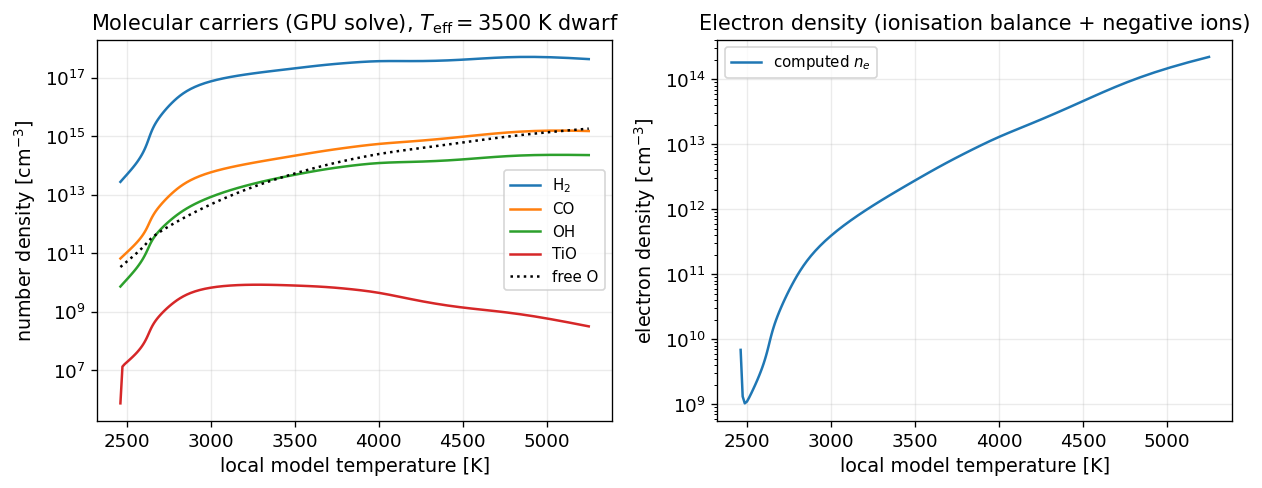

In [21]:
def mol_index(target):
    """Return the row index whose Kurucz molecule code is closest to target."""
    return int(np.argmin(np.abs(code_mol[:nummol] - target)))
idx_H2, idx_CO, idx_OH, idx_TiO = mol_index(101.0), mol_index(608.0), mol_index(108.0), mol_index(822.0)
o_eq = int(np.where(idequa[:nequa] == 8)[0][0]); n_O_free = xnz_g[:, o_eq]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10.5, 4.2))
ax1.semilogy(T, xnmol_g[:, idx_H2], label="H$_2$")
ax1.semilogy(T, xnmol_g[:, idx_CO], label="CO")
ax1.semilogy(T, xnmol_g[:, idx_OH], label="OH")
ax1.semilogy(T, xnmol_g[:, idx_TiO], label="TiO")
ax1.semilogy(T, n_O_free, "k:", label="free O")
ax1.set_xlabel("local model temperature [K]"); ax1.set_ylabel("number density [cm$^{-3}$]")
ax1.set_title("Molecular carriers (GPU solve), $T_{\\rm eff}=3500$ K dwarf"); ax1.legend(fontsize=9)
ax2.semilogy(T, electron_g, label="computed $n_e$")
ax2.set_xlabel("local model temperature [K]"); ax2.set_ylabel("electron density [cm$^{-3}$]")
ax2.set_title("Electron density (ionisation balance + negative ions)"); ax2.legend(fontsize=9)
fig.tight_layout(); plt.show()

## Part 2 — Molecular continuous opacity

### Why a cool dwarf's continuum is not the Sun's

A warm star's continuum is H$^-$ — bound-free and free-free absorption by the negative hydrogen ion (Lecture 3). That source weakens in a cool dwarf (less ionisation means fewer free electrons to make H$^-$), while molecular continuum terms become important. In the **blue and ultraviolet**, the CH and OH radicals add true **bound-free** continuous absorption — molecular photodissociation, in which a photon energetic enough to break the bond ejects the molecule into unbound fragments (CH$\,+\,h\nu \rightarrow$ C$\,+\,$H). Because the final state is a continuum of relative energies, the cross-section is smooth rather than a forest of lines. In the **near-infrared**, where an M dwarf radiates much of its luminosity, the dominant *molecular* continuum source included here is **collision-induced absorption by molecular hydrogen** (H$_2$-CIA). A lone H$_2$ is symmetric with no permanent dipole, so its transitions are electric-dipole forbidden; but during a collision (two H$_2$, or H$_2$+He) the transient pair has an **induced dipole** for the femtoseconds of the encounter, and that dipole-allowed channel is the strong absorber. At fixed temperature and composition, because two particles must meet, the *volume* coefficient scales as density-squared; expressed as a mass opacity it grows about linearly. We build all three molecular terms (CHOP, OHOP, H$_2$-CIA) from the atmosphere state and Borysow tables.

**The tensor shape of Part 2.** Unlike Part 1, there is no sequential dependency here — each opacity is a direct table interpolation, independent at every depth and frequency. So the continuum becomes one **depth-batched `[D, F]` tensor computation**: instead of looping over frequency and over depth inside each species function, torch evaluates the whole $[80, 600]$ grid at once. Every band-index bracket, table gather, and bilinear interpolation is a batched tensor op, and the inactive-region cutoffs ($T \ge 9000$ K, energy outside the band, wavenumber $> 20000$ cm$^{-1}$) are branchless `torch.where` masks. This runs fp32 on the GPU at the $\sim10^{-7}$ floor.

### Loading the continuum inputs and the coefficient tables

The continuum needs the atmosphere state (temperature, mass density, the H ground-state and He I populations) plus the molecular-equilibrium populations of CH and OH (`xnfpch`, `xnfpoh` — Kurucz-style mode-1 $N/U$ populations; multiplying by the interpolated partition function restores the absorber density used by the cross-section table). This is the continuum fixture boundary: in the full pipeline those state populations are supplied by the EOS/equilibrium stages; in this standalone lecture they are loaded only to hold the input state fixed while we test the CH/OH/H$_2$ continuum implementation. The wavelength grid spans 300–5000 nm so we see both the blue CH/OH region and the near-infrared H$_2$-CIA region. The tables are the CH/OH cross-section and partition-function tables and the Borysow H$_2$–H$_2$ / H$_2$–He CIA coefficient tables. The accepted `mol_continuum` port reads them straight from the npz, so we pass the loaded archive through.

In [22]:
mc = np.load(REF / "mol_continuum_inputs.npz")
wavelength_nm = mc["wavelength_nm"].astype(float)       # nm
frequency_hz = mc["frequency_hz"].astype(float)         # Hz
continuum_temperature = mc["temperature"].astype(float) # K (same cool dwarf as Part 1)
num_continuum_layers, num_wavelengths = continuum_temperature.size, frequency_hz.size
print(f"continuum grid: {num_continuum_layers} layers x {num_wavelengths} wavelengths, "
      f"{wavelength_nm.min():.0f}-{wavelength_nm.max():.0f} nm, "
      f"T = {continuum_temperature.min():.0f}-{continuum_temperature.max():.0f} K")
print("tables:", [k for k in mc.files if k.isupper()])

continuum grid: 80 layers x 600 wavelengths, 300-5000 nm, T = 2464-5250 K
tables: ['CH_PARTITION', 'OH_PARTITION', 'CH_CROSSSECT', 'OH_CROSSSECT', 'H2_COLL_H2H2', 'H2_COLL_H2HE']


### The shared physical constants and the device adapters

The continuum code keeps its own constants (matching the Fortran values) and small adapters: `_cpu64` / `_cpu_long` move host arrays onto the working device as fp64/long tensors, `_trunc_i64` is the integer truncation the band-index math needs, and `_finish` moves the final result onto the notebook's device in its working dtype (fp32 on MPS, fp64 on CPU).

In [23]:
C_LIGHT_CM = 2.99792458e10      # cm/s
H_PLANCK = 6.62607015e-27       # erg s
K_BOLTZ = 1.380649e-16          # erg/K
KBOLTZ_EV_F = 8.6171e-5         # eV/K, the Fortran TKEV constant
LN10 = 2.30258509299405

_CPU = torch.device("cpu"); _F64 = torch.float64

def _np64(inp, name):
    """Read one named fixture array as host fp64."""
    return np.asarray(inp[name], dtype=np.float64)

def _cpu64(a):
    """Move a host array to contiguous CPU/fp64 for table interpolation."""
    return torch.as_tensor(np.ascontiguousarray(a), dtype=_F64, device=_CPU)

def _cpu_long(a):
    """Move an index array to contiguous CPU/int64 for torch gathers."""
    return torch.as_tensor(np.ascontiguousarray(a), dtype=torch.long, device=_CPU)

def _trunc_i64(x):
    """Fortran-style integer truncation used by the table-cell arithmetic."""
    return np.trunc(x).astype(np.int64)

def _finish(x):
    """Move the finished opacity onto the notebook's device in its working dtype."""
    if DEVICE.type == "cpu" and DTYPE is torch.float64:
        return x
    return x.to(device=DEVICE, dtype=DTYPE)

print("continuum constants + device adapters ready")

continuum constants + device adapters ready


### CH and OH continuous opacity (CHOP / OHOP): the frequency-row interpolation

CHOP and OHOP share one structure, so the code factors it into `_band_frequency_rows`: given the whole frequency grid it forms the photon energy in eV, computes the band-energy index branchlessly (`_trunc_i64(ev*10)` with a per-species shift — CH starts at 0.2 eV, OH at 2.1 eV), brackets the cross-section table in energy, and **gathers two adjacent table rows and linearly interpolates** them — `lo + (hi - lo)*frac` — for *every* frequency at once. The inactive region (energy outside the band) is zeroed by a `torch.where` over the `valid` mask, not skipped by a Python `if/return`. This collapses the loop over frequency into one batched gather + interpolation.

In [24]:
def _band_frequency_rows(frequency_hz, cross_section_table, species):
    """Interpolate the CH/OH cross-section table in PHOTON ENERGY for all frequencies at once."""
    wavenumber_cm1 = frequency_hz / C_LIGHT_CM; photon_energy_ev = wavenumber_cm1 / 8065.479
    if species == "CH":
        energy_bin = _trunc_i64(photon_energy_ev * 10.0)
        lower_energy_ev = energy_bin.astype(np.float64) * 0.1
        table_row = energy_bin - 2
        valid = (energy_bin >= 20) & (energy_bin < 105) & (table_row >= 0) & (table_row < 104)
    else:  # OH: energy index shifted by 2.0 eV (table starts at 2.1 eV)
        energy_bin = _trunc_i64(photon_energy_ev * 10.0) - 20
        lower_energy_ev = energy_bin.astype(np.float64) * 0.1 + 2.0
        table_row = energy_bin - 1
        valid = (energy_bin > 0) & (energy_bin < 130) & (table_row >= 0) & (table_row < 129)
    safe_table_row = np.clip(table_row, 0, cross_section_table.shape[0] - 2)
    energy_weight = _cpu64((photon_energy_ev - lower_energy_ev) / 0.1)
    table = _cpu64(cross_section_table); table_row_t = _cpu_long(safe_table_row)
    lower_row = table.index_select(0, table_row_t); upper_row = table.index_select(0, table_row_t + 1)
    rows = lower_row + (upper_row - lower_row) * energy_weight[:, None]  # linear interp in energy, all freqs
    valid_t = torch.as_tensor(np.ascontiguousarray(valid), dtype=torch.bool, device=_CPU)
    rows = torch.where(valid_t[:, None], rows, torch.zeros_like(rows))   # branchless band cutoff
    return rows, valid_t, valid_t.to(_F64)

print("_band_frequency_rows ready")

_band_frequency_rows ready


### The depth-batched temperature interpolation and the CH/OH continuum

`_band_continuum` finishes the job: it interpolates the energy-interpolated rows in **temperature** (500 K bins from 2000 K) across all depths, applies the partition function (also $T$-interpolated, by `_partition_per_depth`), converts $\log_{10}(\sigma U)$ with $10^x = e^{x\ln 10}$, and multiplies by the population $n/\rho$ and the stimulated-emission factor — all as `[D, F]` tensor ops with the active-region mask folded in branchlessly. The opacity per gram is $\sigma U \cdot (n_{\rm mol}/\rho)\,(1-e^{-h\nu/kT})$.

In [25]:
def _partition_per_depth(partition, temperature):
    """CH/OH partition function, linear in T (200 K bins from 1000 K), per depth."""
    it = np.clip(_trunc_i64((temperature - 1000.0) / 200.0), 0, 39)
    tn = it.astype(np.float64) * 200.0 + 1000.0
    return partition[it] + (partition[it + 1] - partition[it]) * (temperature - tn) / 200.0

def _cross_temp_cell(temperature):
    """Cross-section T-cell (500 K bins from 2000 K)."""
    it = np.clip(_trunc_i64((temperature - 2000.0) / 500.0), 0, 13)
    tn = it.astype(np.float64) * 500.0 + 2000.0
    return it, (temperature - tn) / 500.0

def _band_continuum(cross_section_rows, valid_bool, valid_float, temperature_cell_index,
                    temperature_weight, partition_function, active_temperature,
                    molecular_number_density, mass_density, stimulated_emission_factor):
    """CH/OH continuum on the [D, F] grid: T-interpolate, exponentiate, apply n/rho and stim."""
    num_temperature_nodes = cross_section_rows.shape[1]
    lower_temperature_cell = temperature_cell_index.clamp(0, num_temperature_nodes - 2)
    upper_temperature_cell = lower_temperature_cell + 1
    lower_cross_section = cross_section_rows.index_select(1, lower_temperature_cell).transpose(0, 1)
    upper_cross_section = cross_section_rows.index_select(1, upper_temperature_cell).transpose(0, 1)
    log_x = lower_cross_section + (upper_cross_section - lower_cross_section) * temperature_weight[:, None]
    safe = valid_bool[None, :] & (active_temperature > 0.0)[:, None]   # branchless active-region mask
    log_x = torch.where(safe, log_x, torch.zeros_like(log_x))
    cross_section_times_partition = torch.exp(log_x * LN10) * partition_function[:, None]
    return (cross_section_times_partition * valid_float[None, :] * active_temperature[:, None]
            * molecular_number_density[:, None] / mass_density[:, None] * stimulated_emission_factor)

print("_band_continuum + temperature-cell helpers ready")

_band_continuum + temperature-cell helpers ready


### The H$_2$ density driving the collision-induced absorption; H$_2$ collision-induced absorption (Borysow), vectorized over frequency and temperature

H$_2$-CIA scales as $n_{\rm H_2}$ times the partner density, so we need $n_{\rm H_2}$ first — from the **same** dissociation polynomial as the code-101 formation constant of Part 1, applied to the H ground-state population: $n_{\rm H_2} = (n_{\rm H,1}\cdot 2\,b_1)^2\,\exp(4.478/kT - 46.4584 + P(T) - \tfrac32\ln T)$, frequency-independent. The Borysow tables give $\log_{10}$ of the absorption coefficient (cm$^5$) on a (wavenumber, temperature) grid; `_h2_frequency_rows` does the **wavenumber** interpolation (250 cm$^{-1}$ bins) for all frequencies at once, masking $> 20000$ cm$^{-1}$ to a $-300$ log floor, and `_temp_lerp_rows` the **temperature** interpolation (1000 K bins).

In [26]:
def _h2_temp_cell(temperature):
    """Borysow H2-CIA temperature-cell index and interpolation weight."""
    it = np.clip(_trunc_i64(temperature / 1000.0), 1, 6)
    delt = np.clip((temperature - 1000.0 * it.astype(np.float64)) / 1000.0, 0.0, 1.0)
    return it, delt

def _h2_frequency_rows(frequency_hz, h2h2_table, h2he_table):
    """Borysow H2-H2 / H2-He tables interpolated in WAVENUMBER for all frequencies at once."""
    wavenumber_cm1 = frequency_hz / C_LIGHT_CM
    wavenumber_cell = np.minimum(79, _trunc_i64(wavenumber_cm1 / 250.0))
    wavenumber_weight = (wavenumber_cm1 - 250.0 * wavenumber_cell.astype(np.float64)) / 250.0
    lower_wavenumber_row = np.clip(np.minimum(wavenumber_cell, 80), 0, 80)
    upper_wavenumber_row = np.clip(np.minimum(wavenumber_cell + 1, 80), 0, 80)
    valid = wavenumber_cm1 <= 20000.0                         # Borysow table/mask range
    lower_row_t = _cpu_long(lower_wavenumber_row); upper_row_t = _cpu_long(upper_wavenumber_row)
    wavenumber_weight_t = _cpu64(wavenumber_weight)
    h2h2 = _cpu64(h2h2_table); h2he = _cpu64(h2he_table)
    h2h2_rows = (h2h2.index_select(0, lower_row_t) * wavenumber_weight_t[:, None]
                 + h2h2.index_select(0, upper_row_t) * (1.0 - wavenumber_weight_t[:, None]))
    h2he_rows = (h2he.index_select(0, lower_row_t) * wavenumber_weight_t[:, None]
                 + h2he.index_select(0, upper_row_t) * (1.0 - wavenumber_weight_t[:, None]))
    valid_t = torch.as_tensor(np.ascontiguousarray(valid), dtype=torch.bool, device=_CPU)
    h2h2_rows = torch.where(valid_t[:, None], h2h2_rows, torch.full_like(h2h2_rows, -300.0))
    h2he_rows = torch.where(valid_t[:, None], h2he_rows, torch.full_like(h2he_rows, -300.0))
    return h2h2_rows, h2he_rows, valid_t, valid_t.to(_F64)

def _temp_lerp_rows(rows_ft, it, delt):
    """Interpolate the (frequency, T-node) rows in temperature, per depth."""
    n_t = rows_ft.shape[1]; it_hi = it.clamp(1, n_t - 1); it_lo = it_hi - 1
    lo = rows_ft.index_select(1, it_lo).transpose(0, 1); hi = rows_ft.index_select(1, it_hi).transpose(0, 1)
    return lo * delt[:, None] + hi * (1.0 - delt[:, None])

def _h2_number_density(temperature, xnfph1, bhyd1):
    """H2 number density from the dissociation polynomial (same physics as the code-101 K_f)."""
    tkev = KBOLTZ_EV_F * temperature; tlog = np.log(temperature)
    poly_t = (1.63660e-3 + (-4.93992e-7 + (1.11822e-10 + (-1.49567e-14
              + (1.06206e-18 - 3.08720e-23 * temperature) * temperature) * temperature)
              * temperature) * temperature) * temperature
    exp_term = np.clip(4.478 / tkev - 46.4584 + poly_t - 1.5 * tlog, -100.0, 100.0)
    return (xnfph1 * 2.0 * bhyd1) ** 2 * np.exp(exp_term)

print("H2 density + Borysow interpolation helpers ready")

H2 density + Borysow interpolation helpers ready


### Computing the molecular continuum over the full grid: `mol_continuum`

The driver assembles everything: it interpolates CH/OH in energy and the Borysow tables in wavenumber (all frequencies at once), builds the per-depth temperature cells and the H$_2$ density, forms the stimulated-emission factor, and combines them into the three `[D, F]` opacities. CHOP and OHOP come from `_band_continuum`; H$_2$-CIA is $(10^{X_{\rm H_2He}} n_{\rm He} + 10^{X_{\rm H_2H_2}} n_{\rm H_2})\,n_{\rm H_2}/\rho\,(1-e^{-h\nu/kT})$ — the two-body, density-squared volume coefficient divided by $\rho$. The total is their sum. This is the **entire continuum in one vectorized pass** over the $[80, 600]$ grid, no Python frequency or depth loop.

In [27]:
def mol_continuum(inp):
    """Molecular continuous opacity (CHOP, OHOP, H2-CIA) on the [D, F] grid, fully vectorized.
    Returns (ch_continuum_absorption, oh_continuum_absorption, h2_cia_absorption,
    continuum_absorption)."""
    temperature = _np64(inp, "temperature"); mass_density = _np64(inp, "mass_density")
    hydrogen_ground_population = _np64(inp, "xnfph1")
    hydrogen_departure_coefficient = _np64(inp, "bhyd1")
    helium_number_density = _np64(inp, "xnfhe1")
    ch_molecular_number_density = _np64(inp, "xnfpch")
    oh_molecular_number_density = _np64(inp, "xnfpoh")
    frequency_hz = _np64(inp, "frequency_hz")
    ch_partition = _np64(inp, "CH_PARTITION"); oh_partition = _np64(inp, "OH_PARTITION")
    ch_crosssect = _np64(inp, "CH_CROSSSECT"); oh_crosssect = _np64(inp, "OH_CROSSSECT")
    h2h2_table = _np64(inp, "H2_COLL_H2H2"); h2he_table = _np64(inp, "H2_COLL_H2HE")

    # frequency-row interpolations (all freqs at once)
    ch_cross, ch_valid_bool, ch_valid = _band_frequency_rows(frequency_hz, ch_crosssect, "CH")
    oh_cross, oh_valid_bool, oh_valid = _band_frequency_rows(frequency_hz, oh_crosssect, "OH")
    h2h2_nu, h2he_nu, h2_valid_bool, h2_valid = _h2_frequency_rows(frequency_hz, h2h2_table, h2he_table)

    # per-depth cells, partitions, H2 density
    ch_part = _partition_per_depth(ch_partition, temperature); oh_part = _partition_per_depth(oh_partition, temperature)
    it_c, wc = _cross_temp_cell(temperature); it_h2, delt = _h2_temp_cell(temperature)
    h2_number_density = _h2_number_density(temperature, hydrogen_ground_population, hydrogen_departure_coefficient)

    temperature_t = _cpu64(temperature); mass_density_t = _cpu64(mass_density)
    helium_number_density_t = _cpu64(helium_number_density)
    ch_molecular_number_density_t = _cpu64(ch_molecular_number_density)
    oh_molecular_number_density_t = _cpu64(oh_molecular_number_density)
    h2_number_density_t = _cpu64(h2_number_density)
    ch_part_t = _cpu64(ch_part); oh_part_t = _cpu64(oh_part); wc_t = _cpu64(wc); delt_t = _cpu64(delt)
    active_t = _cpu64((temperature < 9000.0).astype(np.float64))     # branchless T-cutoff
    it_c_t = _cpu_long(it_c); it_h2_t = _cpu_long(it_h2)

    frequency_temperature_t = _cpu64(H_PLANCK * frequency_hz / K_BOLTZ)
    stimulated_emission_factor = 1.0 - torch.exp(-frequency_temperature_t[None, :] / temperature_t[:, None])

    ch_continuum_absorption64 = _band_continuum(ch_cross, ch_valid_bool, ch_valid, it_c_t, wc_t,
                                                ch_part_t, active_t, ch_molecular_number_density_t,
                                                mass_density_t, stimulated_emission_factor)
    oh_continuum_absorption64 = _band_continuum(oh_cross, oh_valid_bool, oh_valid, it_c_t, wc_t,
                                                oh_part_t, active_t, oh_molecular_number_density_t,
                                                mass_density_t, stimulated_emission_factor)

    xh2h2 = _temp_lerp_rows(h2h2_nu, it_h2_t, delt_t); xh2he = _temp_lerp_rows(h2he_nu, it_h2_t, delt_t)
    xh2h2 = torch.where(h2_valid_bool[None, :], xh2h2, torch.full_like(xh2h2, -300.0))
    xh2he = torch.where(h2_valid_bool[None, :], xh2he, torch.full_like(xh2he, -300.0))
    ten = torch.tensor(10.0, dtype=_F64, device=_CPU)
    h2_cia_absorption64 = ((torch.pow(ten, xh2he) * helium_number_density_t[:, None]
                            + torch.pow(ten, xh2h2) * h2_number_density_t[:, None])
                           * h2_number_density_t[:, None] / mass_density_t[:, None]
                           * stimulated_emission_factor * h2_valid[None, :])
    continuum_absorption64 = ch_continuum_absorption64 + oh_continuum_absorption64 + h2_cia_absorption64
    return (_finish(ch_continuum_absorption64), _finish(oh_continuum_absorption64),
            _finish(h2_cia_absorption64), _finish(continuum_absorption64))

t0 = time.time()
ch_continuum_absorption, oh_continuum_absorption, h2_cia_absorption, continuum_absorption = mol_continuum(mc)
print(f"molecular continuum computed over the {num_continuum_layers}x{num_wavelengths} grid in {time.time()-t0:.3f}s "
      f"(device {DEVICE.type})")

molecular continuum computed over the 80x600 grid in 0.012s (device mps)


### Benchmark: the torch continuum against the inline fp64 reference

We validate the torch `mol_continuum` against the inline fp64 reference (the scalar reference from `verify_mol_continuum.py` — CHOP/OHOP/H2COLLOP with their Python frequency loops — the parity oracle) and against the shipped ground truth, reporting `max|rel|` on CH, OH, H$_2$-CIA, and the total molecular continuum absorption.

First we prepare the scalar reference tables and the shared thermodynamic factors. The CH/OH cross-section helper and the H$_2$-CIA helper are defined in separate cells below because they are independent pieces of physics.

In [28]:
# --- the inline fp64 reference: scalar CHOP/OHOP/H2COLLOP, the parity oracle ---
temperature_ref = mc["temperature"].astype(float); mass_density_ref = mc["mass_density"].astype(float)
hydrogen_ground_population_ref = mc["xnfph1"].astype(float)
hydrogen_departure_coefficient_ref = mc["bhyd1"].astype(float)
helium_number_density_ref = mc["xnfhe1"].astype(float)
ch_molecular_number_density_ref = mc["xnfpch"].astype(float)
oh_molecular_number_density_ref = mc["xnfpoh"].astype(float)
CH_PARTITION = mc["CH_PARTITION"]; OH_PARTITION = mc["OH_PARTITION"]
CH_CROSSSECT = mc["CH_CROSSSECT"]; OH_CROSSSECT = mc["OH_CROSSSECT"]
H2H2 = mc["H2_COLL_H2H2"]; H2HE = mc["H2_COLL_H2HE"]
tkev_ref = KBOLTZ_EV_F * temperature_ref; tlog_ref = np.log(temperature_ref)
stimulated_emission_ref = 1.0 - np.exp(-H_PLANCK * frequency_hz[None, :] / (K_BOLTZ * temperature_ref[:, None]))
poly_temperature_ref = (1.63660e-3 + (-4.93992e-7 + (1.11822e-10 + (-1.49567e-14
                        + (1.06206e-18 - 3.08720e-23 * temperature_ref) * temperature_ref)
                        * temperature_ref) * temperature_ref) * temperature_ref) * temperature_ref
h2_number_density_ref = ((hydrogen_ground_population_ref * 2.0 * hydrogen_departure_coefficient_ref) ** 2
                         * np.exp(np.clip(4.478 / tkev_ref - 46.4584 + poly_temperature_ref
                                          - 1.5 * tlog_ref, -100, 100)))
print("fp64 reference: continuum tables and thermodynamic factors ready")

fp64 reference: continuum tables and thermodynamic factors ready


The CH/OH reference helper is the scalar version of the same table interpolation used by the torch path: choose the photon-energy bracket, interpolate the cross-section table, then interpolate the partition function and temperature row at each depth.

In [29]:
# --- fp64 reference: scalar CHOP/OHOP band interpolation ---

def _band_xsect_np(freq_scalar, CROSS, PART, n_off, idx_off, en_off, n_lo, n_hi, idx_hi):
    """Scalar CH/OH cross-section lookup used only by the fp64 parity oracle."""
    out = np.zeros(temperature_ref.size); wn = freq_scalar / C_LIGHT_CM; ev = wn / 8065.479   # numpy-ref
    n = int(ev * 10) - n_off
    if n <= n_lo or n >= n_hi: return out
    en = n * 0.1 + en_off; idx = n - idx_off
    if idx < 0 or idx >= idx_hi: return out
    cross = CROSS[idx] + (CROSS[idx + 1] - CROSS[idx]) * (ev - en) / 0.1
    for j in range(temperature_ref.size):   # numpy-ref
        tj = temperature_ref[j]
        if tj >= 9000.0: continue
        it_p = max(0, min(int((tj - 1000.0) / 200.0), 39)); tn_p = it_p * 200.0 + 1000.0
        part = PART[it_p] + (PART[it_p + 1] - PART[it_p]) * (tj - tn_p) / 200.0
        it_c = max(0, min(int((tj - 2000.0) / 500.0), 13)); tn_c = it_c * 500.0 + 2000.0
        log_x = cross[it_c] + (cross[it_c + 1] - cross[it_c]) * (tj - tn_c) / 500.0
        out[j] = np.exp(log_x * LN10) * part   # numpy-ref
    return out
print("fp64 reference: scalar CHOP/OHOP helper ready")

fp64 reference: scalar CHOP/OHOP helper ready


The H$_2$-CIA helper is the scalar Borysow-table lookup: interpolate in wavenumber, then in temperature, and multiply by the H$_2$ and He perturber densities.

In [30]:
# --- fp64 reference: scalar H2 collision-induced absorption ---

def h2cia_np(freq_scalar, stim_col):
    """Scalar Borysow H2-CIA lookup used only by the fp64 parity oracle."""
    out = np.zeros(temperature_ref.size); wn = freq_scalar / C_LIGHT_CM   # numpy-ref
    if wn > 20000.0: return out
    nu = min(79, int(wn / 250.0)); delnu = (wn - 250.0 * nu) / 250.0
    idx1 = min(nu, 80); idx2 = min(nu + 1, 80)
    h2h2_nu = H2H2[idx1] * delnu + H2H2[idx2] * (1.0 - delnu)
    h2he_nu = H2HE[idx1] * delnu + H2HE[idx2] * (1.0 - delnu)
    for j in range(temperature_ref.size):   # numpy-ref
        tj = temperature_ref[j]; it = max(1, min(6, int(tj / 1000.0)))
        delt = max(0.0, min(1.0, (tj - 1000.0 * it) / 1000.0))
        xh2h2 = h2h2_nu[it - 1] * delt + h2h2_nu[it] * (1.0 - delt)
        xh2he = h2he_nu[it - 1] * delt + h2he_nu[it] * (1.0 - delt)
        out[j] = ((10.0 ** xh2he * helium_number_density_ref[j]
                   + 10.0 ** xh2h2 * h2_number_density_ref[j])
                  * h2_number_density_ref[j] / mass_density_ref[j] * stim_col[j])
    return out

print("fp64 reference: scalar H2-CIA helper ready")

fp64 reference: scalar H2-CIA helper ready


Finally assemble the fp64 reference continuum over the same frequency grid. This is the comparison
target for the torch continuum cell above; it is not fed back into the taught calculation.

In [31]:
# numpy-ref: assemble the fp64-reference reference arrays (the parity targets) over the frequency grid
ch_continuum_absorption_ref = np.zeros((num_continuum_layers, num_wavelengths))
oh_continuum_absorption_ref = np.zeros((num_continuum_layers, num_wavelengths))
h2_cia_absorption_ref = np.zeros((num_continuum_layers, num_wavelengths))
for j in range(num_wavelengths):   # numpy-ref: the scalar twin's frequency loop (the oracle, not the shipped torch path)
    frequency_j = frequency_hz[j]; stimulated_emission_j = stimulated_emission_ref[:, j]
    ch_continuum_absorption_ref[:, j] = (
        _band_xsect_np(frequency_j, CH_CROSSSECT, CH_PARTITION, 0, 2, 0.0, 19, 105, 104)
        * ch_molecular_number_density_ref / mass_density_ref * stimulated_emission_j)
    oh_continuum_absorption_ref[:, j] = (
        _band_xsect_np(frequency_j, OH_CROSSSECT, OH_PARTITION, 20, 1, 2.0, 0, 130, 129)
        * oh_molecular_number_density_ref / mass_density_ref * stimulated_emission_j)
    h2_cia_absorption_ref[:, j] = h2cia_np(frequency_j, stimulated_emission_j)
continuum_absorption_ref = ch_continuum_absorption_ref + oh_continuum_absorption_ref + h2_cia_absorption_ref

# COMPARISON ONLY: pykurucz ground truth, never used in the computation
truth = np.load(REF / "mol_continuum_truth.npz")
print("GPU torch mol_continuum  vs  inline fp64 reference:")
compare("CHOP   (CH)     ", ch_continuum_absorption, ch_continuum_absorption_ref, tol=1e-6, floor=0.0)
compare("OHOP   (OH)     ", oh_continuum_absorption, oh_continuum_absorption_ref, tol=1e-6, floor=0.0)
compare("H2-CIA (Borysow)", h2_cia_absorption, h2_cia_absorption_ref, tol=1e-6, floor=0.0)
compare("MOL TOTAL       ", continuum_absorption, continuum_absorption_ref, tol=1e-6, floor=0.0)
print("\nGPU torch mol_continuum  vs  pykurucz ground truth:")
rc = compare("CHOP   (CH)     ", ch_continuum_absorption, truth["chop"], tol=1e-6, floor=0.0)
ro = compare("OHOP   (OH)     ", oh_continuum_absorption, truth["ohop"], tol=1e-6, floor=0.0)
rh = compare("H2-CIA (Borysow)", h2_cia_absorption, truth["h2cia"], tol=1e-6, floor=0.0)
rt = compare("MOL TOTAL       ", continuum_absorption, truth["mol_total"], tol=1e-6, floor=0.0)
is_fp32 = (DTYPE == torch.float32)
floor_c = 1e-6 if is_fp32 else 1e-10
worst_c = max(rc, ro, rh, rt)
print(f"\nmolecular continuum max relative error = {worst_c:.3e}   floor = {floor_c:.0e}   ->",
      "[PASS]" if worst_c < floor_c else "[CHECK]")
assert worst_c < floor_c, f"continuum deviates by {worst_c:.2e}, above the float floor {floor_c:.0e}"

GPU torch mol_continuum  vs  inline fp64 reference:
CHOP   (CH)                   max|rel diff| = 5.85e-08   [agree]   (n=3280)
OHOP   (OH)                   max|rel diff| = 5.87e-08   [agree]   (n=3040)
H2-CIA (Borysow)              max|rel diff| = 5.94e-08   [agree]   (n=45920)
MOL TOTAL                     max|rel diff| = 5.94e-08   [agree]   (n=48000)

GPU torch mol_continuum  vs  pykurucz ground truth:
CHOP   (CH)                   max|rel diff| = 5.85e-08   [agree]   (n=3280)
OHOP   (OH)                   max|rel diff| = 5.87e-08   [agree]   (n=3040)
H2-CIA (Borysow)              max|rel diff| = 5.94e-08   [agree]   (n=45920)
MOL TOTAL                     max|rel diff| = 5.94e-08   [agree]   (n=48000)

molecular continuum max relative error = 5.941e-08   floor = 1e-06   -> [PASS]


**What the number means.** The torch `mol_continuum` matches both the inline fp64 reference and pykurucz to $\sim6\times10^{-8}$ (fp32 on MPS) — single-precision round-off of the table interpolation and the exponentiation, *not* a physics difference. On a CPU/fp64 run it is bit-exact. The branchless `torch.where` band cutoffs select the same active region as the scalar `if/return`, the flat-gather table reads reproduce the same bilinear interpolation, and the whole $[80, 600]$ grid is evaluated in one vectorized pass instead of a double Python loop over frequency and depth.

### H$_2$-CIA is the dominant molecular near-infrared continuum here

The physical payoff. At a representative cool photospheric layer ($T\approx3000$ K), the three species at four wavelengths from blue to near-infrared: CH and OH carry the blue *molecular* continuum, but from about 1 $\mu$m outward their bound-free tables contribute zero beyond their tabulated/energetic ranges and H$_2$-CIA is the dominant molecular-continuum term — overlapping a large fraction of the near-infrared flux an M dwarf emits.

In [32]:
ch_continuum_absorption_plot = ch_continuum_absorption.detach().cpu().double().numpy()  # JUSTIFY: reporting/plot boundary
oh_continuum_absorption_plot = oh_continuum_absorption.detach().cpu().double().numpy()  # JUSTIFY: reporting/plot boundary
h2_cia_absorption_plot = h2_cia_absorption.detach().cpu().double().numpy()  # JUSTIFY: reporting/plot boundary
continuum_absorption_plot = continuum_absorption.detach().cpu().double().numpy()  # JUSTIFY: reporting/plot boundary

jcool = int(np.argmin(np.abs(continuum_temperature - 3000.0)))     # numpy-ref: a results-readout cell (host-side print of the torch result)
print(f"H2-CIA dominance at T = {continuum_temperature[jcool]:.0f} K:")
for target in (450.0, 1000.0, 1500.0, 2200.0):       # JUSTIFIED-LOOP: 4 fixed readout wavelengths, blue -> near-IR
    i = int(np.argmin(np.abs(wavelength_nm - target))); total_at_wavelength = continuum_absorption_plot[jcool, i]   # numpy-ref
    fraction_h2_cia = (h2_cia_absorption_plot[jcool, i] / total_at_wavelength * 100.0) if total_at_wavelength > 0 else 0.0
    print(f"  {wavelength_nm[i]:6.0f} nm : CHOP={ch_continuum_absorption_plot[jcool,i]:.3e} "
          f"OHOP={oh_continuum_absorption_plot[jcool,i]:.3e} "
          f"H2CIA={h2_cia_absorption_plot[jcool,i]:.3e}  ->  H2-CIA = {fraction_h2_cia:5.1f}% of mol continuum")

H2-CIA dominance at T = 3001 K:
     449 nm : CHOP=1.118e-08 OHOP=1.484e-07 H2CIA=0.000e+00  ->  H2-CIA =   0.0% of mol continuum
     998 nm : CHOP=0.000e+00 OHOP=0.000e+00 H2CIA=1.290e-06  ->  H2-CIA = 100.0% of mol continuum
    1501 nm : CHOP=0.000e+00 OHOP=0.000e+00 H2CIA=2.538e-05  ->  H2-CIA = 100.0% of mol continuum
    2199 nm : CHOP=0.000e+00 OHOP=0.000e+00 H2CIA=1.724e-04  ->  H2-CIA = 100.0% of mol continuum


The molecular continuum across the whole grid at the deepest layer of the cool-dwarf model ($T\approx5250$ K — a *local* layer temperature, the warmest, densest base of the $T_{\rm eff}=3500$ K photosphere, where the density-squared H$_2$-CIA is largest). CH and OH appear as blue/near-UV bumps; the Borysow CIA table is used only for $\tilde\nu \le 20000\ {\rm cm^{-1}}$ ($\lambda \gtrsim 500$ nm), and within that tabulated range H$_2$-CIA dominates the molecular contribution through the near-infrared.

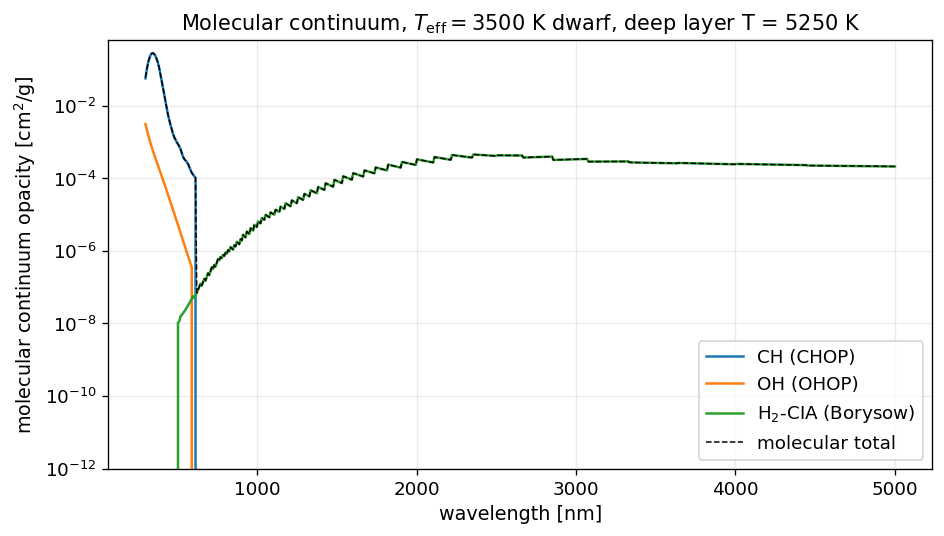

In [33]:
jdeep = num_continuum_layers - 1
fig, ax = plt.subplots(figsize=(8.0, 4.6))
ax.plot(wavelength_nm, ch_continuum_absorption_plot[jdeep], label="CH (CHOP)")
ax.plot(wavelength_nm, oh_continuum_absorption_plot[jdeep], label="OH (OHOP)")
ax.plot(wavelength_nm, h2_cia_absorption_plot[jdeep], label="H$_2$-CIA (Borysow)")
ax.plot(wavelength_nm, continuum_absorption_plot[jdeep], "k--", lw=0.9, label="molecular total")
ax.set_yscale("log"); ax.set_xlabel("wavelength [nm]")
ax.set_ylabel("molecular continuum opacity [cm$^2$/g]")
ax.set_title(f"Molecular continuum, $T_{{\\rm eff}}=3500$ K dwarf, deep layer T = {continuum_temperature[jdeep]:.0f} K")
ax.set_ylim(1e-12, None); ax.legend()
fig.tight_layout(); plt.show()

## Synthesis

The two halves of this lecture are the two pieces Lecture 12 took on credit, now paid in full — and rebuilt the GPU way.

**The chemistry is coupled, and we vectorized exactly the right part of it.** A single formation constant $K_f(T)$ gives one molecule's density *if* you already know the free-atom densities — but you do not, because every element is shared among competing molecules and $n_e$ feeds back through negative ions. The honest object is the coupled system: a total-particle/pressure closure, one nuclei-conservation equation per element, charge balance, every molecule's mass-action term. We solved it the production way — Newton–Raphson with damping — but recast the solver into its torch form: the **inner Newton iteration** became dense tensor algebra, with an **autodiff `jacrev` Jacobian** replacing the hand-coded `DEQ`, a **branchless log-space residual** built from a precomputed incidence structure, and a **column-scaled `torch.linalg.solve`** conditioning the $\sim$25-dex Jacobian in one LAPACK call instead of SOLVIT's scalar elimination loop. The **depth loop stayed a loop** because this implementation uses the converged previous depth as a warm start; the depths are physically local, but the continuation strategy is robust. That division — *vectorize what is independent, keep the continuation loop that makes the stiff solve converge* — is the lecture's central GPU lesson, and we were honest about the precision: the stiff solve runs in **fp64 on CPU**, the reference path, where the autodiff Newton reaches the same equilibrium as the Fortran DEQ+SOLVIT to a $\sim10^{-13}$ float64 floor.

**The continuum is molecular, and vectorizes cleanly.** A cool dwarf's continuum is not the Sun's H$^-$. CH and OH add bound-free photodissociation absorption in the blue; H$_2$ collision-induced absorption — a transient collision complex with an induced dipole — dominates the *molecular* near-infrared continuum from 1 to 2.2 $\mu$m in this model. With no sequential dependency, the continuum becomes one depth-batched `[80, 600]` tensor computation: every band-index bracket, table gather, and bilinear interpolation a batched op, every inactive-region cutoff a branchless `torch.where`. It runs fp32 on the GPU and matches the inline fp64 reference to $\sim6\times10^{-8}$.

With these in hand, the cool-star molecular physics is no longer just quoted from the reference. The remaining integration boundary is stated plainly: this continuum cell still consumes reference atmosphere-state populations for parity, and the full capstone must wire those state producers into the synthesis path. **Lecture 14** assembles every component built so far — the equation of state, the continuum, the atomic and hydrogen and helium lines, these molecular bands and continuum, and the JOSH transfer — into one lean synthesiser and runs the **emergent spectrum end to end** across stars spanning the HR diagram.

## Summary

- **Molecular chemistry is a coupled problem.** Elements are shared among competing molecules and negative ions tie the chemistry to $n_e$, so a per-molecule $K_f$ is an *input*, not the answer: one **total-particle/pressure closure**, one **number-conservation** equation per element, one **charge-balance** equation, every molecule depositing its mass-action term $n_{\rm mol}=K_f\prod_i n_i$ (with $K_f$ carrying the density units required by the stoichiometry and ion entries handled by electron or inverse-electron factors in the component list).
- **The Newton iteration vectorizes; the depth loop is retained for robust continuation.** At one depth the step is an **autodiff (`jacrev`) Jacobian** + a **column-scaled `torch.linalg.solve`** over the $n_{\rm equa}$ unknowns, with the residual built **branchlessly in log space** from a precomputed incidence structure (`MolStructure`). The depth loop **stays a loop** because depth $j$ is warm-started from converged depth $j-1$; that is a numerical convergence strategy, not a physical cross-depth coupling.
- **Autodiff replaces the hand-coded Jacobian.** `jacrev` differentiates the implemented residual, so the Jacobian cannot drift out of sync with that model away from clamps/masks; column scaling conditions the $\sim$25-dex Jacobian in one LAPACK call and plays a similar stabilizing role to the legacy pivoting strategy for this validated system.
- **Precision honesty.** The stiff coupled solve runs in **fp64 on CPU** (the reference path); it reaches the same equilibrium as the production Fortran DEQ+SOLVIT to a $\sim10^{-13}$ float64 non-associativity floor, with $K_f(T)$ **bit-exact**.
- **The molecular continuum vectorizes cleanly.** **CH** (CHOP) and **OH** (OHOP) photodissociation and **H$_2$-CIA** (Borysow) are one depth-batched `[80, 600]` table interpolation, all cutoffs branchless; it runs fp32 on the GPU and matches the twin to $\sim6\times10^{-8}$.
- **H$_2$-CIA dominates the molecular continuum from 1 to 2.2 $\mu$m in this model**, overlapping much of the M dwarf's emergent flux — a two-body induced-dipole process whose *volume* coefficient goes as density-squared at fixed temperature and composition (the mass opacity, $\div\rho$, then rises only about linearly).

## Practice exercises

**1. Who owns the oxygen?** Using the GPU-converged `xnz_g` and `xnmol_g`, sum the oxygen nuclei locked in each O-bearing molecule (CO, OH, TiO, ...) plus free O, and confirm the total equals the oxygen abundance times $n_0$. Which molecule carries the most oxygen at 3000 K, and why? (Hint: compare $D_0$.)

**2. The depth loop really is sequential.** Modify `_nmolec_driver` to **cold-seed every depth** (use the $j=0$ seed at all depths instead of the warm-start `xn_prev_conv * ratio`). Watch the deep, stiff layers take far more iterations — or fail to converge in 200 — and time the slowdown. This is the experiment that justifies keeping the depth loop: the warm-start chain is load-bearing.

**3. Autodiff vs hand-DEQ.** Pick one depth and one iteration. Print the `jacrev` Jacobian `J` and the inline fp64 reference's hand-coded `DEQ` for the same state. Confirm they agree to fp64 round-off away from clamps/masks — the autodiff Jacobian is the derivative of the implemented residual.

**4. Column scaling matters.** In `_newton_step`, drop the column scaling (solve `J @ d = eq` directly) and re-run the solve. Watch the residual stall or the populations degrade at the depths where the Jacobian's dynamic range is widest. Explain how scaling by $|x_n|$ stabilizes the differently scaled unknowns, and how that differs from SOLVIT's complete pivoting.

**5. The induced-dipole scaling.** Take two depths differing in density by $\sim10\times$ and confirm the H$_2$-CIA *volume* coefficient ratio (multiply the mass opacity by $\rho$) is close to the *square* of the density ratio, while the mass opacity itself rises only about linearly. Contrast with a one-body process.

**6. Where H$_2$-CIA takes over.** From `chop_g`/`ohop_g`/`h2cia_g` at the cool layer, find the wavelength where H$_2$-CIA overtakes CH+OH, and explain why it falls near 1 $\mu$m for this M-dwarf model (Planck peak, CH/OH table ranges, and the Borysow CIA table mask at $\tilde\nu=20000\ {\rm cm^{-1}}$).

## Further reading

- **Russell, H. N. (1934). *Astrophys. J.* 79, 317.** "Molecules in the Sun and Stars" — the classic application of the law of mass action to the molecular composition of stellar atmospheres.
- **Tatum, J. B. (1966). *Publ. Dom. Astrophys. Obs.* 13, 1.** The molecular partition-function and equilibrium-constant formalism underlying the $\log K(T)$ polynomial fits used here.
- **Borysow, A., Jorgensen, U. G. & Zheng, C. (1997). *Astron. Astrophys.* 324, 185.** Collision-induced absorption of H$_2$–H$_2$ — the source of the H$_2$-CIA tables and the near-infrared continuum of cool dwarfs.
- **Tsuji, T. (1973). *Astron. Astrophys.* 23, 411.** Molecular abundances in cool stellar atmospheres — the coupled-equilibrium treatment and the C/O dividing line between M and C stars.
- **Kurucz, R. L. (1970). *SAO Special Report* 309 (ATLAS).** The NMOLEC molecular-equilibrium routine, the SOLVIT linear solver, and the CHOP/OHOP/H2COLLOP continuous-opacity functions reproduced here.
- **Griewank, A. & Walther, A. (2008). *Evaluating Derivatives: Principles and Techniques of Algorithmic Differentiation*, 2nd ed., SIAM.** The reverse-mode automatic differentiation (`jacrev`) that produces the Newton Jacobian here from the residual itself.
- **Kim, E. M. & Ting, Y.-S. (2026). [*pykurucz*](https://arxiv.org/abs/2603.11693).** The implementation our reference populations and molecular continuum are computed with.